# **Project Name** - Airbnb NYC 2019: Exploratory Data Analysis

##### **Project Type** - EDA (Exploratory Data Analysis)
##### **Contribution** - Individual
##### **Team Member 1** - Sanjeev Goyal

# **Project Summary -**

Since 2008, Airbnb has grown into one of the world's largest marketplaces for short stays, and New York City is one of its biggest and most closely regulated markets. This project explores the Airbnb NYC 2019 dataset — 48,895 listings with 16 columns describing the host, location, room type, nightly price, minimum stay, reviews and availability over the next year — to understand how supply, price and guest demand are spread across the city, and what that means for Airbnb, its hosts and its guests.

The work follows the standard EDA workflow. Profiling found no duplicates, and almost all missing values sit in `last_review` and `reviews_per_month` (10,052 rows each). Every one of those rows is a listing that has never been reviewed, so the gaps are structural: `reviews_per_month` was set to 0 and `last_review` was converted to a date, with blanks meaning "never reviewed". Missing names were labelled "Unknown". Eleven listings priced at \$0 and fourteen with a minimum stay over a year were removed (25 rows), leaving 48,870 listings. Because price is extremely right-skewed (maximum \$10,000), price distributions are plotted up to the 99th percentile (\$799), while medians and means use all cleaned data. New features were added: price band, host type and portfolio size, stay type (under or over 30 nights), availability band, review recency and a "likely dormant" flag.

Twenty-five charts were then built following the UBM rule — univariate, bivariate (numerical–categorical, numerical–numerical and categorical–categorical) and multivariate analysis — and each one answers why it was chosen, what it shows and how the insight affects the business.

Key findings:
- **Supply is concentrated.** Manhattan (44.3%) and Brooklyn (41.1%) hold 85% of listings; the Bronx and Staten Island together hold 3%. Ten of 221 neighbourhoods account for 48% of supply.
- **Location and room type set the price.** The median Manhattan listing costs \$150 a night against \$65 in the Bronx, and an entire home costs more than twice a private room (\$160 vs \$70). The ten most expensive neighbourhoods are all in Manhattan, led by Tribeca.
- **Price does not buy demand.** Price and review count are almost unrelated (r = −0.05); listings priced at \$500 or more average 11 reviews against about 25 for listings under \$200. Shorter minimum stays bring far more reviews per month.
- **Much of the supply looks inactive.** 36% of listings have no open dates in the next year and 21% have never been reviewed; about a quarter are both fully blocked and without a review in the past year.
- **Professional hosts behave differently.** 86% of hosts list a single home, yet multi-listing hosts control a third of listings. Operators such as Sonder and Blueground run hundreds of Manhattan apartments open most of the year, and hosts with 11+ listings require 30+ nights on most of them — closer to corporate housing than home sharing.
- **The outer boroughs are under-served.** Staten Island, the Bronx and Queens have few listings but about twice the review rate of Manhattan and Brooklyn, and the busiest hosts are budget private-room hosts — three of them next to LaGuardia Airport.

The recommendations are to recruit hosts in the high-demand outer boroughs, give hosts location- and room-type-aware price guidance, re-activate or de-rank dormant listings, help new listings win their first booking, monitor high-volume operators for compliance with New York's rules on stays under 30 days, and market affordable private rooms and homes outside Manhattan to value-seeking travellers. Together, these actions can grow bookings and host earnings, improve guest trust and reduce regulatory risk.

# **GitHub Link -**

**GitHub repository:** https://github.com/sanjeevgoyal1993/Airbnb-NYC-2019-EDA

# **Problem Statement**

Since 2008, guests and hosts have used Airbnb to travel in a more personal way, and the millions of listings on the platform generate data that can guide security, business decisions, marketing and new services. In 2019 Airbnb had about 49,000 listings in New York City, but the raw data does not show:

- where listings are concentrated and where supply is thin;
- what drives the nightly price (borough, neighbourhood, room type, stay length);
- which listings, hosts and areas attract the most guest activity — and why;
- how casual home-sharers differ from professional, multi-listing hosts;
- how much of the listed supply is actually active.

Without these answers hosts mis-price their homes, supply piles up where competition is already intense, dormant listings clutter search results, and commercial-scale hosting creates regulatory risk. This project explores and visualises the 2019 listings data to answer these questions and turns the findings into recommendations.

#### **Define Your Business Objective?**

Use the Airbnb NYC 2019 data to help Airbnb's business, host-success and marketing teams:

1. **Understand supply** — how listings are distributed by borough, neighbourhood, room type and host.
2. **Understand pricing** — which factors explain the nightly price and where the price outliers are.
3. **Understand demand** — which listings, hosts and areas get the most reviews and why. Reviews are used as a proxy for bookings, because the dataset has no booking counts.
4. **Spot risk** — inactive listings and commercial-style hosting that can hurt guest trust or attract regulation.
5. **Recommend actions** that increase bookings and host earnings while improving the guest experience.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# ---------------- Import libraries ----------------
import warnings

import numpy as np                     # fast numerical operations
import pandas as pd                    # data loading, cleaning and aggregation
import matplotlib                      # used for the version check below
import matplotlib.pyplot as plt        # plotting
import matplotlib.ticker as mtick      # percentage axis formatting
import seaborn as sns                  # statistical charts

# Library deprecation notices are not errors; hide them so the output stays readable
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Display and plotting defaults used throughout the notebook
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 100,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
})

print(f"pandas {pd.__version__} | numpy {np.__version__} | "
      f"matplotlib {matplotlib.__version__} | seaborn {sns.__version__}")

pandas 2.2.3 | numpy 2.1.3 | matplotlib 3.10.0 | seaborn 0.13.2


### Dataset Loading

In [2]:
# ---------------- Load the dataset ----------------
# Public CSV export of the course's "Airbnb NYC 2019" file (no login needed)
DATA_URL = ("https://docs.google.com/spreadsheets/d/1uEcOuaGBgLPVFZ5SQE99B38CzzhxbN83/"
            "export?format=csv&gid=1074862307")
LOCAL_FILE = "Airbnb NYC 2019.csv"     # fallback: upload this file to the Colab session if the link is unreachable

EXPECTED_COLUMNS = [
    "id", "name", "host_id", "host_name", "neighbourhood_group", "neighbourhood",
    "latitude", "longitude", "room_type", "price", "minimum_nights", "number_of_reviews",
    "last_review", "reviews_per_month", "calculated_host_listings_count", "availability_365",
]


def load_airbnb_data(url=DATA_URL, local_file=LOCAL_FILE):
    """Read the dataset from the public URL, fall back to a local copy, and check its columns."""
    try:
        data = pd.read_csv(url)
        source = "public URL"
    except Exception as url_error:                     # no internet, link moved, etc.
        print(f"Could not read the URL ({type(url_error).__name__}); trying '{local_file}' ...")
        try:
            data = pd.read_csv(local_file)
            source = f"local file '{local_file}'"
        except FileNotFoundError as file_error:
            raise FileNotFoundError(
                f"Dataset not found. Upload '{local_file}' to the Colab Files pane and run this cell again."
            ) from file_error

    missing_columns = sorted(set(EXPECTED_COLUMNS) - set(data.columns))
    if missing_columns:
        raise ValueError(f"The dataset is missing expected columns: {missing_columns}")

    print(f"Loaded {len(data):,} rows x {data.shape[1]} columns from the {source}.")
    return data[EXPECTED_COLUMNS]


df_raw = load_airbnb_data()

Loaded 48,895 rows x 16 columns from the public URL.


### Dataset First View

In [3]:
# First five listings
df_raw.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.65,-73.97,Private room,149,1,9,19/10/2018,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75,-73.98,Entire home/apt,225,1,45,21/5/2019,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.81,-73.94,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.69,-73.96,Entire home/apt,89,1,270,5/7/2019,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.80,-73.94,Entire home/apt,80,10,9,19/11/2018,0.10,1,0


### Dataset Rows & Columns count

In [4]:
# Number of rows (listings) and columns (attributes)
rows, columns = df_raw.shape
print(f"Rows: {rows:,} | Columns: {columns}")

Rows: 48,895 | Columns: 16


### Dataset Information

In [5]:
# Column data types and non-null counts
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

#### Duplicate Values

In [6]:
# Fully duplicated rows and repeated listing ids
print(f"Duplicate rows       : {df_raw.duplicated().sum()}")
print(f"Duplicate listing ids: {df_raw['id'].duplicated().sum()}")

Duplicate rows       : 0
Duplicate listing ids: 0


#### Missing Values/Null Values

In [7]:
# Missing values per column: count and % of rows
missing = df_raw.isnull().sum().to_frame("missing_count")
missing["missing_%"] = (missing["missing_count"] / len(df_raw) * 100).round(2)
missing.sort_values("missing_count", ascending=False)

,missing_count,missing_%
last_review,10052,20.56
reviews_per_month,10052,20.56
host_name,21,0.04
name,16,0.03
neighbourhood_group,0,0.00
neighbourhood,0,0.00
id,0,0.00
host_id,0,0.00
longitude,0,0.00
latitude,0,0.00


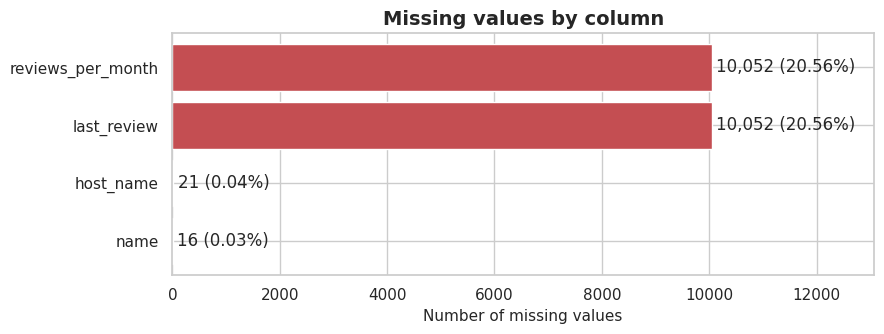

last_review: 10,052 missing, of which 10,052 are listings with 0 reviews
reviews_per_month: 10,052 missing, of which 10,052 are listings with 0 reviews


In [8]:
# Visualizing the missing values (only the columns that have gaps)
missing_only = missing[missing["missing_count"] > 0].sort_values("missing_count")

fig, ax = plt.subplots(figsize=(9, 3.5))
bars = ax.barh(missing_only.index, missing_only["missing_count"], color="#C44E52")
ax.bar_label(bars, padding=3,
             labels=[f"{n:,} ({p}%)" for n, p in zip(missing_only["missing_count"], missing_only["missing_%"])])
ax.set_xlim(0, missing_only["missing_count"].max() * 1.3)
ax.set_title("Missing values by column")
ax.set_xlabel("Number of missing values")
plt.tight_layout()
plt.show()

# Are the missing review fields explained by listings that were never reviewed?
never_reviewed = df_raw["number_of_reviews"].eq(0)
for col in ["last_review", "reviews_per_month"]:
    gaps = df_raw[col].isnull()
    print(f"{col}: {gaps.sum():,} missing, of which {(gaps & never_reviewed).sum():,} are listings with 0 reviews")

### What did you know about your dataset?

- The dataset lists **48,895 Airbnb listings in New York City** with **16 columns**. The latest review is dated 8 July 2019, so it is a mid-2019 snapshot.
- **10 numeric columns** (ids, latitude/longitude, price, minimum nights, review counts, host listing count, availability) and **6 text columns** (listing name, host name, borough, neighbourhood, room type, and `last_review`, which is stored as text and must be converted to a date).
- **No duplicates**: no repeated rows and no repeated listing ids.
- **Missing values:** `last_review` and `reviews_per_month` have 10,052 gaps each (20.6%), and every one belongs to a listing with 0 reviews. They are structural, not errors. `name` (16) and `host_name` (21) have a handful.
- **Data-quality issues to fix:** 11 listings priced at \$0, minimum stays of up to 1,250 nights, and extreme prices up to \$10,000.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
print(list(df_raw.columns))

['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


In [10]:
# Dataset Describe: numeric columns
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
id,"48,895.00","19,017,143.24","10,983,108.39","2,539.00","9,471,945.00","19,677,284.00","29,152,178.50","36,487,245.00"
host_id,"48,895.00","67,620,010.65","78,610,967.03","2,438.00","7,822,033.00","30,793,816.00","107,434,423.00","274,321,313.00"
latitude,"48,895.00",40.73,0.05,40.50,40.69,40.72,40.76,40.91
longitude,"48,895.00",-73.95,0.05,-74.24,-73.98,-73.96,-73.94,-73.71
price,"48,895.00",152.72,240.15,0.00,69.00,106.00,175.00,"10,000.00"
minimum_nights,"48,895.00",7.03,20.51,1.00,1.00,3.00,5.00,"1,250.00"
number_of_reviews,"48,895.00",23.27,44.55,0.00,1.00,5.00,24.00,629.00
reviews_per_month,"38,843.00",1.37,1.68,0.01,0.19,0.72,2.02,58.50
calculated_host_listings_count,"48,895.00",7.14,32.95,1.00,1.00,1.00,2.00,327.00
availability_365,"48,895.00",112.78,131.62,0.00,0.00,45.00,227.00,365.00


In [11]:
# Dataset Describe: text / categorical columns
df_raw.describe(exclude=[np.number]).T

,count,unique,top,freq
name,48879,47896,Hillside Hotel,18
host_name,48874,11452,Michael,417
neighbourhood_group,48895,5,Manhattan,21661
neighbourhood,48895,221,Williamsburg,3920
room_type,48895,3,Entire home/apt,25409
last_review,38843,1764,23/6/2019,1413


### Variables Description

| Variable | Type | Description |
|---|---|---|
| `id` | Integer | Unique listing id |
| `name` | Text | Listing title written by the host |
| `host_id` | Integer | Unique host id |
| `host_name` | Text | Host's first name (or company name) |
| `neighbourhood_group` | Categorical | Borough: Manhattan, Brooklyn, Queens, Bronx, Staten Island |
| `neighbourhood` | Categorical | Neighbourhood inside the borough (221 in total) |
| `latitude`, `longitude` | Float | Location of the listing |
| `room_type` | Categorical | Entire home/apt, Private room or Shared room |
| `price` | Integer | Nightly price in US dollars |
| `minimum_nights` | Integer | Minimum number of nights per booking |
| `number_of_reviews` | Integer | Total reviews received |
| `last_review` | Date (stored as text) | Date of the most recent review |
| `reviews_per_month` | Float | Average reviews per month |
| `calculated_host_listings_count` | Integer | Number of listings the host has in this dataset |
| `availability_365` | Integer | Days the listing is open for booking in the next 365 days |

### Check Unique Values for each variable.

In [12]:
# Number of distinct values in every column
display(df_raw.nunique().sort_values(ascending=False).to_frame("unique_values"))

# Categories of the low-cardinality columns
for col in ["neighbourhood_group", "room_type"]:
    print(f"{col}: {sorted(df_raw[col].dropna().unique())}")

,unique_values
id,48895
name,47896
host_id,37457
latitude,19048
longitude,14718
host_name,11452
last_review,1764
reviews_per_month,937
price,674
number_of_reviews,394


neighbourhood_group: ['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island']
room_type: ['Entire home/apt', 'Private room', 'Shared room']


## 3. ***Data Wrangling***

### Data Wrangling Code

In [13]:
# ---------------- Data wrangling, part 1: cleaning ----------------
df = df_raw.copy()                                     # keep the raw data untouched

# 1) Text fields: fill the few missing names and collapse repeated spaces
for col in ["name", "host_name"]:
    df[col] = df[col].fillna("Unknown").astype(str).str.replace(r"\s+", " ", regex=True).str.strip()

# 2) A listing with no reviews has a review rate of 0, not "unknown"
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)


def parse_dates(series, formats=("%d/%m/%Y", "%Y-%m-%d", "%m/%d/%Y")):
    """Convert text dates to datetime using whichever known format parses the most values."""
    best = None
    for fmt in formats:
        parsed = pd.to_datetime(series, format=fmt, errors="coerce")
        if best is None or parsed.notna().sum() > best.notna().sum():
            best = parsed
    return best


# 3) last_review: text -> datetime (a blank stays NaT = never reviewed)
df["last_review"] = parse_dates(df["last_review"])
unparsed = df_raw["last_review"].notna().sum() - df["last_review"].notna().sum()
print(f"last_review converted: {df['last_review'].notna().sum():,} dates, {unparsed} values could not be parsed")

# 4) Remove invalid listings: free (price 0) listings and minimum stays longer than a year
invalid_price = df["price"].le(0)
invalid_nights = df["minimum_nights"].gt(365)
print(f"Removing {invalid_price.sum()} listings with price 0 and {invalid_nights.sum()} with minimum_nights > 365")
df = df.loc[~(invalid_price | invalid_nights)].reset_index(drop=True)
print(f"Rows after cleaning: {len(df):,} (removed {len(df_raw) - len(df)})")

last_review converted: 38,843 dates, 0 values could not be parsed
Removing 11 listings with price 0 and 14 with minimum_nights > 365
Rows after cleaning: 48,870 (removed 25)


In [14]:
# ---------------- Data wrangling, part 2: new features ----------------
SNAPSHOT_DATE = df["last_review"].max()                # latest review = when the data was collected

# Price band (bins are closed on the left, so a 100 USD listing is "Mid")
PRICE_BAND_LABELS = ["Budget (<$100)", "Mid ($100-199)", "Premium ($200-499)", "Luxury ($500+)"]
df["price_band"] = pd.cut(df["price"], bins=[0, 100, 200, 500, np.inf], labels=PRICE_BAND_LABELS, right=False)

# Host type and portfolio size, from the host's listing count
df["host_type"] = np.where(df["calculated_host_listings_count"] > 1, "Multi-listing host", "Single-listing host")
HOST_PORTFOLIO_LABELS = ["1", "2", "3-5", "6-10", "11+"]
df["host_portfolio"] = pd.cut(df["calculated_host_listings_count"], bins=[0, 1, 2, 5, 10, np.inf],
                              labels=HOST_PORTFOLIO_LABELS)

# Stay type: New York treats stays of 30+ nights differently from short-term stays
df["stay_type"] = np.where(df["minimum_nights"] >= 30, "Long stay (30+ nights)", "Short stay (<30 nights)")

# Availability band over the next 365 days
df["availability_band"] = pd.cut(df["availability_365"], bins=[-1, 0, 90, 180, 300, 365],
                                 labels=["0 days", "1-90", "91-180", "181-300", "301-365"])

# Review activity and recency
df["has_reviews"] = df["number_of_reviews"].gt(0)
df["last_review_year"] = df["last_review"].dt.year.astype("Int64")
df["last_review_month"] = df["last_review"].dt.month.astype("Int64")
df["days_since_last_review"] = (SNAPSHOT_DATE - df["last_review"]).dt.days

# Likely dormant: no open date in the next year AND no review in the last 12 months (or never reviewed)
df["is_dormant"] = df["availability_365"].eq(0) & (
    df["days_since_last_review"].isna() | df["days_since_last_review"].gt(365))

# Copy without the top 1% of prices, used ONLY for distribution/scatter charts
# (all medians and means in this notebook use the full cleaned data)
PRICE_CAP = df["price"].quantile(0.99)
dfp = df[df["price"] <= PRICE_CAP].copy()

print(f"Data snapshot date (latest review): {SNAPSHOT_DATE:%d %b %Y}")
print(f"99th-percentile price cap for distribution charts: {PRICE_CAP:,.0f} USD -> {len(dfp):,} listings in those charts")
print(f"Likely dormant listings: {df['is_dormant'].sum():,} ({df['is_dormant'].mean():.1%})")
df.head()

Data snapshot date (latest review): 08 Jul 2019
99th-percentile price cap for distribution charts: 799 USD -> 48,396 listings in those charts
Likely dormant listings: 12,585 (25.8%)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,price_band,host_type,host_portfolio,stay_type,availability_band,has_reviews,last_review_year,last_review_month,days_since_last_review,is_dormant
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.65,-73.97,Private room,149,1,9,2018-10-19,0.21,6,365,Mid ($100-199),Multi-listing host,6-10,Short stay (<30 nights),301-365,True,2018,10,262.00,False
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75,-73.98,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,Premium ($200-499),Multi-listing host,2,Short stay (<30 nights),301-365,True,2019,5,48.00,False
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.81,-73.94,Private room,150,3,0,NaT,0.00,1,365,Mid ($100-199),Single-listing host,1,Short stay (<30 nights),301-365,False,<NA>,<NA>,NaN,False
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.69,-73.96,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,Budget (<$100),Single-listing host,1,Short stay (<30 nights),181-300,True,2019,7,3.00,False
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.80,-73.94,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,Budget (<$100),Single-listing host,1,Short stay (<30 nights),0 days,True,2018,11,231.00,False


In [15]:
# ---------------- Sanity checks: stop early if the cleaned data breaks an assumption ----------------
checks = {
    "all prices are positive": df["price"].gt(0).all(),
    "minimum_nights is between 1 and 365": df["minimum_nights"].between(1, 365).all(),
    "no missing names, host names or review rates": df[["name", "host_name", "reviews_per_month"]].notna().all().all(),
    "every reviewed listing has a last_review date": df.loc[df["has_reviews"], "last_review"].notna().all(),
    "listing ids are unique": df["id"].is_unique,
}
for check, passed in checks.items():
    print(f"{'PASS' if passed else 'FAIL'} - {check}")
if not all(checks.values()):
    raise ValueError("Data checks failed - review the wrangling steps above.")

PASS - all prices are positive
PASS - minimum_nights is between 1 and 365
PASS - no missing names, host names or review rates
PASS - every reviewed listing has a last_review date
PASS - listing ids are unique


### What all manipulations have you done and insights you found?

**Manipulations**
1. Copied the raw data to `df` so the original stays untouched.
2. Filled 16 missing listing names and 21 missing host names with "Unknown" and collapsed repeated spaces in names (for example "Brooklyn&nbsp;&nbsp;&nbsp;Breakfast" becomes "Brooklyn& Breakfast").
3. Filled the 10,052 missing `reviews_per_month` values with 0, since every one belongs to a listing with zero reviews.
4. Converted `last_review` from text (day/month/year) to a real date. Blanks stay empty, meaning "never reviewed".
5. Removed 25 invalid listings: 11 priced at \$0 and 14 with a minimum stay above 365 nights (the maximum was 1,250). **48,870 listings remain.**
6. Added features: `price_band`, `host_type`, `host_portfolio`, `stay_type`, `availability_band`, `has_reviews`, `last_review_year` / `last_review_month`, `days_since_last_review` and `is_dormant`.
7. Created `dfp`, a copy without the top 1% of prices (above \$799). It is used only for distribution and scatter charts so extreme prices don't squash them; every median and mean uses the full cleaned data.
8. Added sanity checks that stop the notebook if the cleaned data breaks an assumption.

**Insights found while wrangling**
- The data is a snapshot taken on **8 July 2019** (the latest review date).
- Missing review fields are structural, not data-entry errors: **20.6% of listings have never been reviewed**.
- Price is extremely skewed (skewness 19, maximum \$10,000), so medians are the right summary.
- About **a quarter of listings (12,585, 25.8%) look dormant**: no availability in the next year and no review in the past 12 months.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

The charts follow the **UBM** rule:
- **4.1 Univariate analysis (Charts 1–9):** one variable at a time — supply, price, stay rules, availability, reviews and hosts.
- **4.2 Bivariate analysis (Charts 10–20):** two variables — numerical–categorical, numerical–numerical and categorical–categorical.
- **4.3 Multivariate analysis (Charts 21–25):** three or more variables — maps, heatmaps and a pair plot.

Every chart is followed by the three questions: *why this chart, what it shows, and how it affects the business.* Reviews are used as a proxy for bookings, because the dataset has no booking counts. Colours stay the same throughout: one colour per borough and one per room type.

In [16]:
# ---------------- Shared settings and helpers for all charts ----------------
BOROUGH_ORDER = df["neighbourhood_group"].value_counts().index.tolist()     # largest -> smallest
ROOM_ORDER = ["Entire home/apt", "Private room", "Shared room"]

BOROUGH_COLORS = dict(zip(BOROUGH_ORDER, sns.color_palette("Set2", len(BOROUGH_ORDER))))
ROOM_COLORS = dict(zip(ROOM_ORDER, ["#4C72B0", "#DD8452", "#55A868"]))


def usd(value):
    """Format a price as $150, or $198.5 when it has a fraction."""
    return f"${value:,.0f}" if float(value).is_integer() else f"${value:,.1f}"


def label_bars(ax, fmt="{:,.0f}", **kwargs):
    """Write each bar's value next to it (vertical or horizontal bars)."""
    for container in ax.containers:
        ax.bar_label(container, labels=[fmt.format(v) for v in container.datavalues], **kwargs)


def finish(ax, title, xlabel=None, ylabel=None):
    """Set the title and axis labels, tidy the layout and show the chart."""
    ax.set_title(title)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    plt.tight_layout()
    plt.show()

### **4.1 Univariate Analysis**

#### Chart - 1 - Listings by borough
*Univariate – categorical*

,listings,share_%
neighbourhood_group,,
Manhattan,21654,44.30
Brooklyn,20089,41.10
Queens,5664,11.60
Bronx,1090,2.20
Staten Island,373,0.80


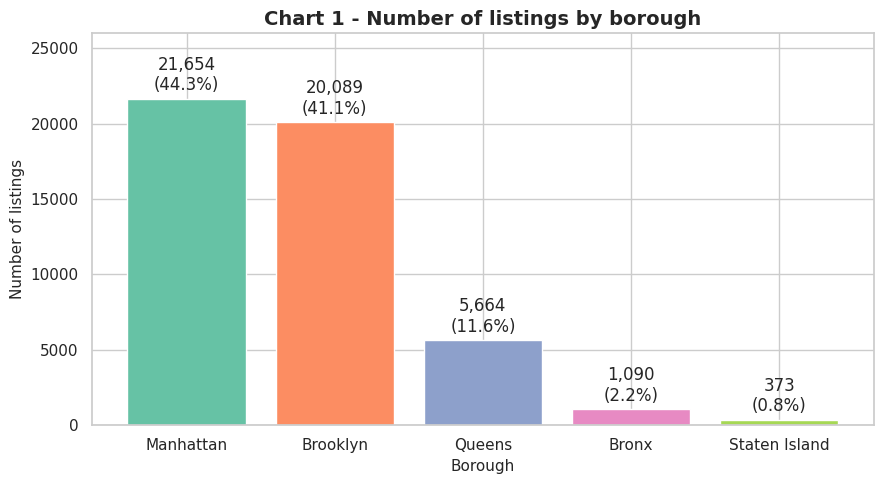

In [17]:
# Chart - 1 visualization code: number of listings per borough
borough_counts = df["neighbourhood_group"].value_counts()
borough_share = borough_counts / borough_counts.sum() * 100
display(pd.DataFrame({"listings": borough_counts, "share_%": borough_share.round(1)}))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(borough_counts.index, borough_counts.values, color=[BOROUGH_COLORS[b] for b in borough_counts.index])
ax.bar_label(bars, labels=[f"{n:,}\n({s:.1f}%)" for n, s in zip(borough_counts, borough_share)], padding=3)
ax.set_ylim(0, borough_counts.max() * 1.2)           # head-room for the labels
finish(ax, "Chart 1 - Number of listings by borough", "Borough", "Number of listings")

##### 1. Why did you pick this chart?
A bar chart is the clearest way to compare counts across a handful of categories. The bars are sorted and labelled with both the count and the share, so the concentration of supply is visible at a glance.

##### 2. What insights did you find?
Manhattan (21,654 listings, 44.3%) and Brooklyn (20,089, 41.1%) together hold **85.4%** of all NYC listings. Queens has 5,664 (11.6%), while the Bronx (1,090, 2.2%) and Staten Island (373, 0.8%) together have **just 3%**.

##### 3. How will these insights impact the business (positive or negative)?
- **Positive:** Airbnb can focus host support, pricing tools and marketing where most of its inventory is. There is also a clear growth gap in the outer boroughs, whose listings are reviewed far more often (Chart 18).
- **Negative:** Relying on two boroughs means fierce competition between hosts there, which puts pressure on price and occupancy. It also concentrates exposure to neighbourhood pushback and local regulation.

#### Chart - 2 - Share of listings by room type
*Univariate – categorical*

,listings,share_%
room_type,,
Entire home/apt,25398,52.00
Private room,22315,45.70
Shared room,1157,2.40


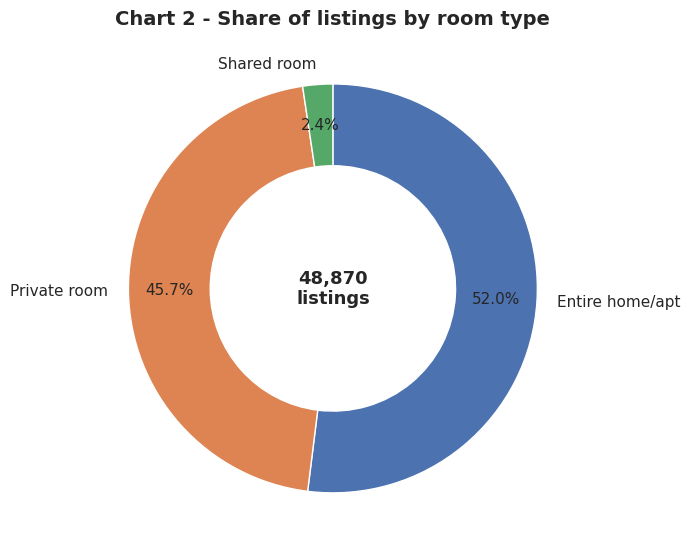

In [18]:
# Chart - 2 visualization code: share of listings by room type (donut chart)
room_counts = df["room_type"].value_counts().reindex(ROOM_ORDER)
display(pd.DataFrame({"listings": room_counts, "share_%": (room_counts / room_counts.sum() * 100).round(1)}))

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(room_counts, labels=room_counts.index, autopct="%1.1f%%", startangle=90, counterclock=False,
       colors=[ROOM_COLORS[r] for r in room_counts.index], pctdistance=0.8,
       wedgeprops={"width": 0.4, "edgecolor": "white"}, textprops={"fontsize": 11})
ax.text(0, 0, f"{room_counts.sum():,}\nlistings", ha="center", va="center", fontsize=13, fontweight="bold")
ax.set_title("Chart 2 - Share of listings by room type")
plt.tight_layout()
plt.show()

##### 1. Why did you pick this chart?
Room type has only three categories that add up to 100%, so a donut chart shows the part-to-whole split directly.

##### 2. What insights did you find?
Entire homes/apartments are **52.0%** of listings, private rooms **45.7%** and shared rooms only **2.4%**. NYC Airbnb is essentially a two-product market.

##### 3. How will these insights impact the business (positive or negative)?
- **Positive:** The mix serves both families and groups (entire homes) and budget solo travellers (private rooms), so marketing can be segmented by product.
- **Negative:** Shared rooms are almost absent, which signals weak demand for them. Entire homes are also the segment New York restricts most: an entire apartment or home may not be rented for fewer than 30 days ([NYC Office of Special Enforcement](https://www.nyc.gov/site/specialenforcement/hosting-STRs/what-is-local-law-18.page)). A supply mix tilted towards entire homes therefore carries compliance risk.

#### Chart - 3 - Distribution of nightly price
*Univariate – numerical*

All cleaned listings: median 106 USD | mean 152.8 USD | skewness 19.12 | max 10,000 USD
Plotted listings    : 48,396 (price <= 799 USD) | median 105 USD | mean 137.6 USD
Most common prices  : 100 USD (2,051), 150 USD (2,047), 50 USD (1,532), 60 USD (1,458), 200 USD (1,401)


,share_of_listings_%
price_band,
Budget (<$100),44.70
Mid ($100-199),35.30
Premium ($200-499),17.50
Luxury ($500+),2.50


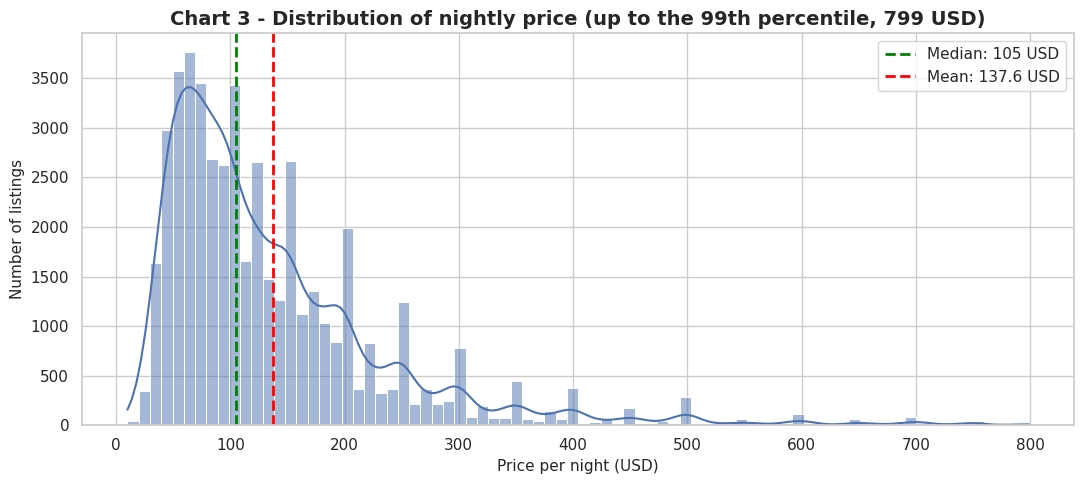

In [19]:
# Chart - 3 visualization code: distribution of nightly price (plotted up to the 99th percentile)
print(f"All cleaned listings: median {df['price'].median():,.0f} USD | mean {df['price'].mean():,.1f} USD | "
      f"skewness {df['price'].skew():.2f} | max {df['price'].max():,} USD")
print(f"Plotted listings    : {len(dfp):,} (price <= {PRICE_CAP:,.0f} USD) | median {dfp['price'].median():,.0f} USD | "
      f"mean {dfp['price'].mean():,.1f} USD")
print("Most common prices  :", ", ".join(f"{p} USD ({n:,})" for p, n in df["price"].value_counts().head(5).items()))
display((df["price_band"].value_counts(normalize=True).sort_index() * 100).round(1).to_frame("share_of_listings_%"))

fig, ax = plt.subplots(figsize=(11, 5))
sns.histplot(dfp["price"], bins=80, kde=True, color="#4C72B0", ax=ax)
ax.axvline(dfp["price"].median(), color="green", ls="--", lw=2, label=f"Median: {dfp['price'].median():,.0f} USD")
ax.axvline(dfp["price"].mean(), color="red", ls="--", lw=2, label=f"Mean: {dfp['price'].mean():,.1f} USD")
ax.legend()
finish(ax, f"Chart 3 - Distribution of nightly price (up to the 99th percentile, {PRICE_CAP:,.0f} USD)",
       "Price per night (USD)", "Number of listings")

##### 1. Why did you pick this chart?
A histogram with a density curve shows the shape of a continuous variable: its centre, spread and skew. The mean and median lines show how much a few expensive listings pull the average. Prices above the 99th percentile (\$799) are left out of the plot only, so the bulk of the distribution stays readable.

##### 2. What insights did you find?
Prices are heavily **right-skewed** (skewness 19.1, maximum \$10,000). The median is **\$106** across all listings, and **80%** of listings cost under \$200 (Budget 44.7% + Mid 35.3%); only 2.5% cost \$500 or more. Even after the cap, the mean (\$137.6) sits well above the median (\$105). The spikes are round numbers: **\$100 and \$150 are the two most common prices** (about 2,050 listings each), followed by \$50 and \$60.

##### 3. How will these insights impact the business (positive or negative)?
- **Positive:** NYC inventory is mostly affordable, which supports booking volume. Reporting and pricing tools should use medians, not means.
- **Negative:** Round-number pricing suggests many hosts guess instead of pricing to demand, so they either lose bookings or leave money on the table. Extreme prices (up to \$10,000) look like errors or placeholders that hurt search quality and guest trust.

#### Chart - 4 - Minimum-night requirement
*Univariate – numerical (grouped)*

Median minimum stay: 3 nights | 3 nights or fewer: 66.3% | 30+ nights: 9.2%


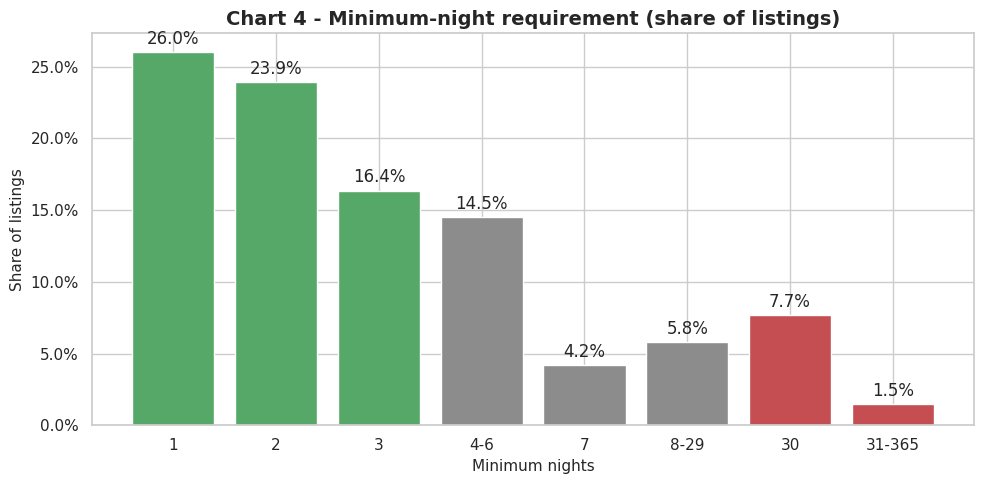

In [20]:
# Chart - 4 visualization code: minimum-night requirement, grouped into meaningful buckets
NIGHT_LABELS = ["1", "2", "3", "4-6", "7", "8-29", "30", "31-365"]
night_bucket = pd.cut(df["minimum_nights"], bins=[0, 1, 2, 3, 6, 7, 29, 30, 365], labels=NIGHT_LABELS)
night_share = night_bucket.value_counts(normalize=True).reindex(NIGHT_LABELS) * 100
print(f"Median minimum stay: {df['minimum_nights'].median():.0f} nights | "
      f"3 nights or fewer: {df['minimum_nights'].le(3).mean():.1%} | 30+ nights: {df['minimum_nights'].ge(30).mean():.1%}")

# green = short stays, red = 30+ nights, grey = everything in between
bar_colors = ["#55A868" if b in ("1", "2", "3") else "#C44E52" if b in ("30", "31-365") else "#8C8C8C"
              for b in NIGHT_LABELS]
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(NIGHT_LABELS, night_share.values, color=bar_colors)
ax.bar_label(bars, labels=[f"{v:.1f}%" for v in night_share.values], padding=3)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
finish(ax, "Chart 4 - Minimum-night requirement (share of listings)", "Minimum nights", "Share of listings")

##### 1. Why did you pick this chart?
Minimum nights is numeric but very skewed and clustered at a few meaningful values (1 night, a week, 30 nights). Grouping it into business-relevant buckets and showing shares makes hosts' stay policies easy to read; a raw histogram would hide them.

##### 2. What insights did you find?
Two-thirds of listings (**66.3%**) accept stays of 3 nights or fewer, and **26.0%** accept a single night; the median is 3 nights. There is a distinct **spike at exactly 30 nights (7.7%)**, and 9.2% of listings require 30 nights or more.

##### 3. How will these insights impact the business (positive or negative)?
- **Positive:** Short, flexible minimums suit tourists and weekend visitors, who are Airbnb's core NYC demand.
- **Negative:** The 30-night spike is consistent with hosts setting minimums to stay clear of New York's restrictions on rentals under 30 days. These listings serve a monthly-rental market: they look like supply but add little to tourist bookings, and they get far fewer reviews (Chart 13).

#### Chart - 5 - Availability over the next 365 days
*Univariate – numerical*

Median 45 days | mean 112.7 days


,share_of_listings_%
availability_band,
0 days,35.90
1-90,24.00
91-180,10.80
181-300,12.80
301-365,16.60


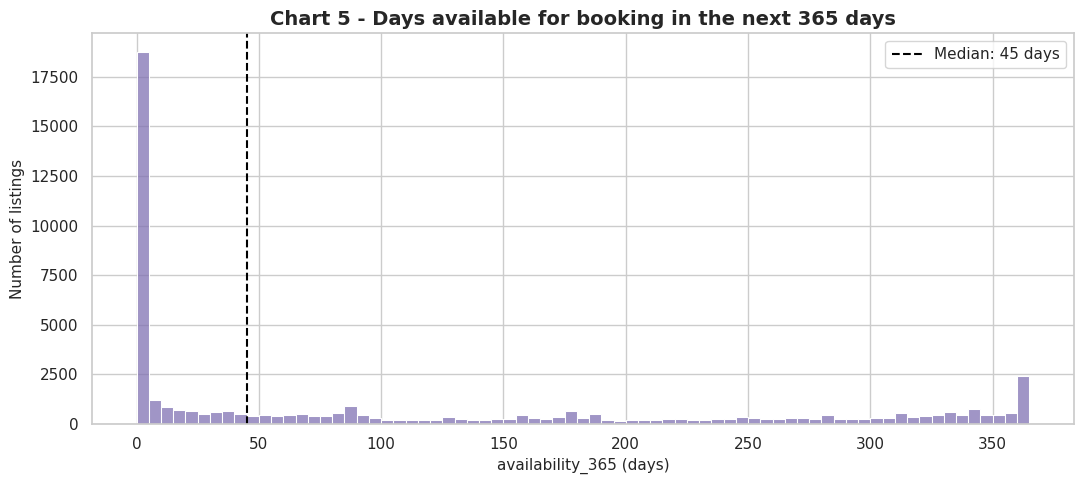

In [21]:
# Chart - 5 visualization code: days available for booking in the next 365 days
avail = df["availability_365"]
print(f"Median {avail.median():.0f} days | mean {avail.mean():.1f} days")
display((df["availability_band"].value_counts(normalize=True).sort_index() * 100).round(1).to_frame("share_of_listings_%"))

fig, ax = plt.subplots(figsize=(11, 5))
sns.histplot(avail, bins=73, color="#8172B3", ax=ax)            # 73 bins = 5-day buckets
ax.axvline(avail.median(), color="black", ls="--", lw=1.5, label=f"Median: {avail.median():.0f} days")
ax.legend()
finish(ax, "Chart 5 - Days available for booking in the next 365 days", "availability_365 (days)", "Number of listings")

##### 1. Why did you pick this chart?
A histogram shows the full shape of availability, including the spike at zero and the cluster of listings that are open all year. A single average would hide both.

##### 2. What insights did you find?
Availability is **polarised**: **35.9%** of listings have **0 days** available in the next year, 24.0% have 1–90 days, and **16.6%** are open 301–365 days. The median is 45 days and the mean 112.7.

##### 3. How will these insights impact the business (positive or negative)?
- **Positive:** Listings open almost all year are dependable supply for planning and for longer stays.
- **Negative:** Over a third of listings cannot be booked at all. Zero can mean "fully booked" or "blocked by the host", but combined with review recency (Chart 7) most look inactive: they inflate supply figures, clutter search and frustrate guests. Year-round availability of entire homes also points to full-time commercial renting rather than home sharing.

#### Chart - 6 - Number of reviews per listing
*Univariate – numerical*

Never reviewed: 20.6% | 1-10 reviews: 41.5% | median 5 | mean 23.3 | over 100 reviews: 6.1% | max 629


,name,host_name,neighbourhood_group,neighbourhood,room_type,price,number_of_reviews
11752,Room near JFK Queen Bed,Dona,Queens,Jamaica,Private room,47,629
2030,Great Bedroom in Manhattan,Jj,Manhattan,Harlem,Private room,49,607
2029,Beautiful Bedroom in Manhattan,Jj,Manhattan,Harlem,Private room,49,597


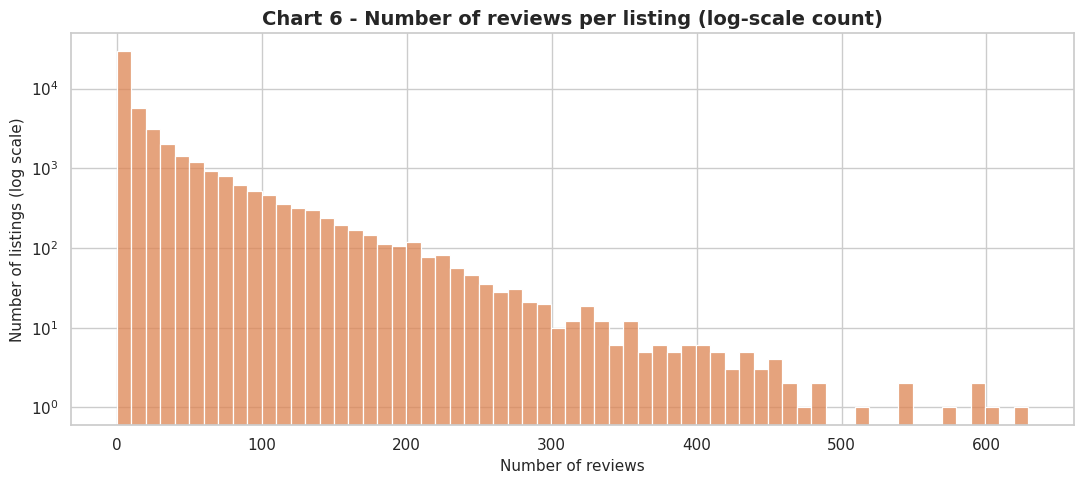

In [22]:
# Chart - 6 visualization code: number of reviews per listing
reviews = df["number_of_reviews"]
print(f"Never reviewed: {reviews.eq(0).mean():.1%} | 1-10 reviews: {reviews.between(1, 10).mean():.1%} | "
      f"median {reviews.median():.0f} | mean {reviews.mean():.1f} | over 100 reviews: {reviews.gt(100).mean():.1%} | "
      f"max {reviews.max()}")
display(df.nlargest(3, "number_of_reviews")[["name", "host_name", "neighbourhood_group", "neighbourhood",
                                             "room_type", "price", "number_of_reviews"]])

fig, ax = plt.subplots(figsize=(11, 5))
sns.histplot(reviews, binwidth=10, color="#DD8452", ax=ax)
ax.set_yscale("log")                       # log scale keeps the long tail visible
finish(ax, "Chart 6 - Number of reviews per listing (log-scale count)", "Number of reviews",
       "Number of listings (log scale)")

##### 1. Why did you pick this chart?
Review counts are extremely skewed. A histogram with a log-scaled count axis shows both the large pile of low-review listings and the long tail of very popular ones.

##### 2. What insights did you find?
**20.6%** of listings have never been reviewed and **41.5%** have only 1–10 reviews (median 5, mean 23.3). Only 6.1% have more than 100 reviews. The most-reviewed listing (**629 reviews**) is a \$47 private room near JFK Airport in Jamaica, Queens, and the next two are \$49 private rooms in Harlem.

##### 3. How will these insights impact the business (positive or negative)?
- **Positive:** The long tail proves that well-priced, well-run listings generate steady bookings. These hosts are role models for host coaching.
- **Negative:** One in five listings has no reviews and therefore no social proof, so guests tend to skip them. First-booking incentives and "new listing" badges could break this cycle.

#### Chart - 7 - Recency: year of the most recent review
*Univariate – date (time trend)*

Snapshot date: 08 Jul 2019 | reviewed listings: 38,827
Last reviewed in 2019: 25,202 (64.9%) | not reviewed since 2018 or earlier: 13,625
Likely dormant (0 days available and no review in the last 12 months): 12,585 (25.8% of all listings)


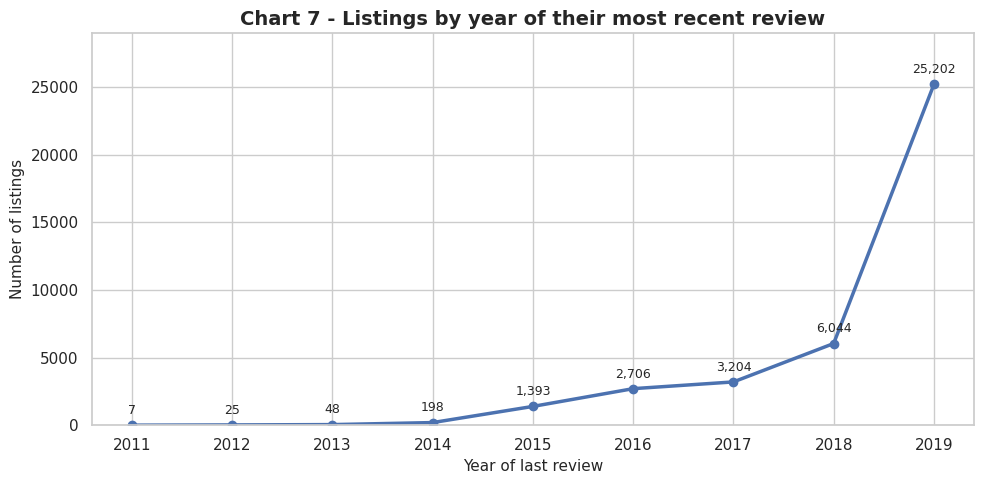

In [23]:
# Chart - 7 visualization code: year of each listing's most recent review
year_counts = df["last_review_year"].value_counts().sort_index()
reviewed_total = year_counts.sum()
reviewed_2019 = year_counts.get(2019, 0)
print(f"Snapshot date: {SNAPSHOT_DATE:%d %b %Y} | reviewed listings: {reviewed_total:,}")
print(f"Last reviewed in 2019: {reviewed_2019:,} ({reviewed_2019 / reviewed_total:.1%}) | "
      f"not reviewed since 2018 or earlier: {year_counts[year_counts.index < 2019].sum():,}")
print(f"Likely dormant (0 days available and no review in the last 12 months): "
      f"{df['is_dormant'].sum():,} ({df['is_dormant'].mean():.1%} of all listings)")

years = year_counts.index.astype(int)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(years, year_counts.values, marker="o", lw=2.5, color="#4C72B0")
for x, y in zip(years, year_counts.values):
    ax.annotate(f"{y:,}", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
ax.set_xticks(years)
ax.set_ylim(0, year_counts.max() * 1.15)
finish(ax, "Chart 7 - Listings by year of their most recent review", "Year of last review", "Number of listings")

##### 1. Why did you pick this chart?
A line chart is the natural way to show counts over time. Here it shows how recent the activity behind each listing is.

##### 2. What insights did you find?
The latest review is dated **8 July 2019**, the snapshot date. Of the 38,827 reviewed listings, **25,202 (64.9%)** were last reviewed in 2019, but **13,625** have not been reviewed since 2018 or earlier — some not since 2011. Combined with availability, **12,585 listings (25.8% of all)** have no open dates in the next year and no review in the last 12 months: they are **likely dormant**.

##### 3. How will these insights impact the business (positive or negative)?
- **Positive:** Most reviewed listings are currently active, which points to a healthy marketplace.
- **Negative:** About a quarter of listings look dormant. They inflate reported supply, waste search space and erode guest trust. Airbnb should prompt these hosts to update their calendars, and de-rank or archive inactive listings.

#### Chart - 8 - Top 10 neighbourhoods by number of listings
*Univariate – categorical*

Top 10 neighbourhoods: 23,430 listings = 47.9% of all listings (out of 221 neighbourhoods)


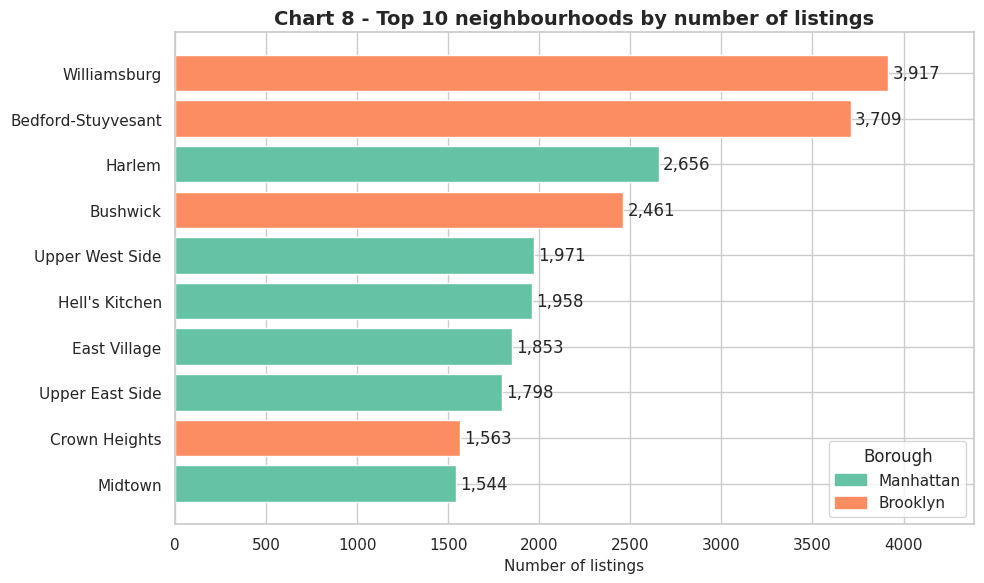

In [24]:
# Chart - 8 visualization code: top 10 neighbourhoods by number of listings
top_nbhd = df["neighbourhood"].value_counts().head(10)
nbhd_borough = df.groupby("neighbourhood")["neighbourhood_group"].first()
print(f"Top 10 neighbourhoods: {top_nbhd.sum():,} listings = {top_nbhd.sum() / len(df):.1%} of all listings "
      f"(out of {df['neighbourhood'].nunique()} neighbourhoods)")

plot_data = top_nbhd.iloc[::-1]                       # largest at the top
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(plot_data.index, plot_data.values, color=[BOROUGH_COLORS[nbhd_borough[n]] for n in plot_data.index])
ax.bar_label(bars, labels=[f"{v:,}" for v in plot_data.values], padding=3)
boroughs_shown = [b for b in BOROUGH_ORDER if b in set(nbhd_borough[top_nbhd.index])]
ax.legend([plt.Rectangle((0, 0), 1, 1, color=BOROUGH_COLORS[b]) for b in boroughs_shown], boroughs_shown,
          title="Borough", loc="lower right")
ax.set_xlim(0, plot_data.max() * 1.12)
finish(ax, "Chart 8 - Top 10 neighbourhoods by number of listings", "Number of listings", "")

##### 1. Why did you pick this chart?
With 221 neighbourhoods, a ranked horizontal bar chart of the top 10 keeps long names readable, and colouring by borough shows where the hotspots are.

##### 2. What insights did you find?
Williamsburg (3,917) and Bedford-Stuyvesant (3,709) in Brooklyn lead, followed by Harlem (2,656), Bushwick (2,461), Upper West Side (1,971) and Hell's Kitchen (1,958). These ten neighbourhoods (four in Brooklyn, six in Manhattan) hold **47.9% of all listings**.

##### 3. How will these insights impact the business (positive or negative)?
- **Positive:** The Brooklyn hotspots sit just across the river from Manhattan, which shows that guests will stay outside Manhattan for a lower price (Chart 22). Airbnb can promote them as "value next to Manhattan".
- **Negative:** Heavy clustering means saturated local competition and more community pushback over housing and noise, which tends to drive regulation.

#### Chart - 9 - Host portfolio size: hosts vs listings
*Univariate – numerical (grouped)*

Hosts: 37,442


,share_of_hosts_%,share_of_listings_%
listings per host,,
1,86.20,66.10
2,8.90,13.60
3-5,4.00,10.50
6-10,0.70,3.70
11+,0.30,6.10


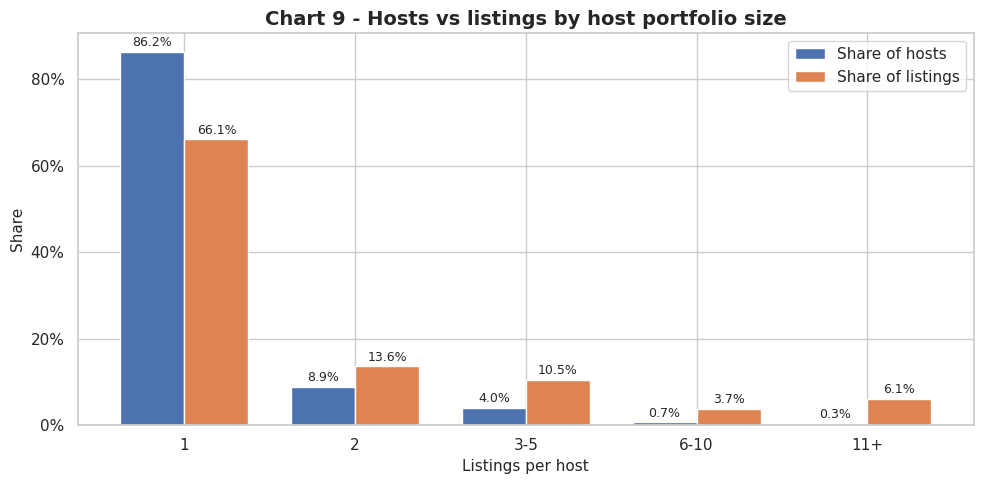

In [25]:
# Chart - 9 visualization code: share of hosts vs share of listings by host portfolio size
host_level = df.groupby("host_id")["host_portfolio"].first()
portfolio = pd.DataFrame({
    "share_of_hosts_%": host_level.value_counts(normalize=True) * 100,
    "share_of_listings_%": df["host_portfolio"].value_counts(normalize=True) * 100,
}).reindex(HOST_PORTFOLIO_LABELS)
portfolio.index.name = "listings per host"
print(f"Hosts: {len(host_level):,}")
display(portfolio.round(1))

ax = portfolio.plot(kind="bar", figsize=(10, 5), color=["#4C72B0", "#DD8452"], rot=0, width=0.75)
label_bars(ax, fmt="{:.1f}%", padding=2, fontsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(["Share of hosts", "Share of listings"])
finish(ax, "Chart 9 - Hosts vs listings by host portfolio size", "Listings per host", "Share")

##### 1. Why did you pick this chart?
A grouped bar chart compares two shares side by side, share of hosts and share of listings. It exposes the gap between "most hosts" and "most supply".

##### 2. What insights did you find?
**86.2%** of the 37,442 hosts have one listing, but together they supply only **66.1%** of listings. Hosts with 6 or more listings are **1.0% of hosts** yet control **9.8% of listings**; hosts with 11+ listings (0.3%) alone hold 6.1%.

##### 3. How will these insights impact the business (positive or negative)?
- **Positive:** The platform is mostly genuine home-sharers, which fits Airbnb's brand. Multi-listing hosts act as professional partners who keep inventory open (Chart 15).
- **Negative:** A small group of commercial operators controls a disproportionate share of supply. That is the kind of activity regulators target, and losing a few of these operators would remove a noticeable block of inventory at once.

### **4.2 Bivariate Analysis**

#### Chart - 10 - Median price by borough
*Bivariate – numerical vs categorical*

,median,mean,listings
neighbourhood_group,,,
Manhattan,150.00,196.90,21654
Brooklyn,90.00,124.50,20089
Queens,75.00,99.50,5664
Staten Island,75.00,114.80,373
Bronx,65.00,87.60,1090


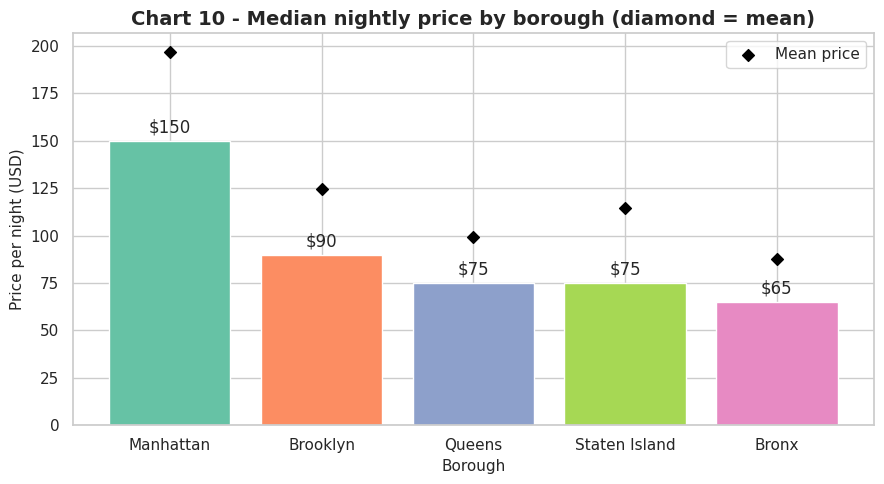

In [26]:
# Chart - 10 visualization code: median (bars) and mean (diamonds) nightly price per borough
borough_price = (df.groupby("neighbourhood_group")["price"]
                   .agg(median="median", mean="mean", listings="size")
                   .sort_values("median", ascending=False))
display(borough_price.round(1))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(borough_price.index, borough_price["median"], color=[BOROUGH_COLORS[b] for b in borough_price.index])
ax.bar_label(bars, labels=[usd(v) for v in borough_price["median"]], padding=3)
ax.scatter(borough_price.index, borough_price["mean"], color="black", marker="D", zorder=3, label="Mean price")
ax.legend()
finish(ax, "Chart 10 - Median nightly price by borough (diamond = mean)", "Borough", "Price per night (USD)")

##### 1. Why did you pick this chart?
Bars of the median price per borough compare typical prices across categories; the median is robust to the outliers seen in Chart 3. A mean marker shows how much expensive listings pull the average up.

##### 2. What insights did you find?
Manhattan is by far the most expensive (**median \$150**, mean \$197), followed by Brooklyn (\$90), Queens and Staten Island (\$75) and the Bronx (**\$65**). A typical Manhattan listing costs **2.3×** one in the Bronx. Means sit above medians everywhere, most of all in Manhattan and Staten Island (mean \$115 against a median of \$75).

##### 3. How will these insights impact the business (positive or negative)?
- **Positive:** Clear price tiers let Airbnb set host price guidance per borough and let guests trade location for budget: a Brooklyn listing costs 60% of the Manhattan median, a short subway ride away.
- **Negative:** Manhattan's high prices compete directly with hotels and push price-sensitive guests to other boroughs. Hosts in cheaper boroughs earn less per night, which can deter new supply there unless occupancy makes up for it.

#### Chart - 11 - Price by room type
*Bivariate – numerical vs categorical*

,count,25%,50%,75%,mean
room_type,,,,,
Entire home/apt,"25,398.00",120.00,160.00,229.00,211.80
Private room,"22,315.00",50.00,70.00,95.00,89.80
Shared room,"1,157.00",33.00,45.00,75.00,70.20


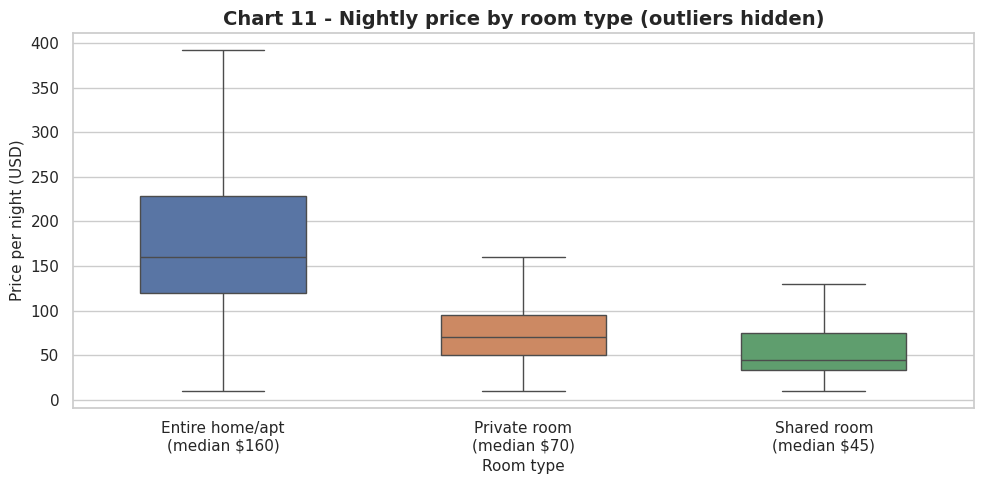

In [27]:
# Chart - 11 visualization code: price distribution by room type (box plot, outliers hidden)
room_price = df.groupby("room_type")["price"].describe().reindex(ROOM_ORDER)[["count", "25%", "50%", "75%", "mean"]]
display(room_price.round(1))

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x="room_type", y="price", order=ROOM_ORDER, hue="room_type", hue_order=ROOM_ORDER,
            palette=ROOM_COLORS, showfliers=False, width=0.55, legend=False, ax=ax)
ax.set_xticks(range(len(ROOM_ORDER)))
ax.set_xticklabels([f"{r}\n(median {usd(room_price.loc[r, '50%'])})" for r in ROOM_ORDER])
finish(ax, "Chart 11 - Nightly price by room type (outliers hidden)", "Room type", "Price per night (USD)")

##### 1. Why did you pick this chart?
A box plot compares the full distribution (median, quartiles and spread) of a numeric variable across categories. Outliers are hidden to keep the boxes readable, because extreme prices were already covered in Chart 3.

##### 2. What insights did you find?
Entire homes have a **median price of \$160** (middle 50%: \$120–229), private rooms **\$70** (\$50–95) and shared rooms **\$45** (\$33–75). An entire home costs about **2.3×** a private room and the boxes barely overlap, so room type is a primary price driver.

##### 3. How will these insights impact the business (positive or negative)?
- **Positive:** A clear price ladder lets Airbnb suggest a price range by room type to new hosts and set guest expectations.
- **Negative:** The shared-room box is wide for its low median: some shared rooms are priced like private rooms. That is poor value for guests and may explain why so few shared rooms exist and why they get the fewest reviews (16.6 on average, against 24.1 for private rooms).

#### Chart - 12 - Price vs number of reviews
*Bivariate – numerical vs numerical*

Pearson r = -0.048 | Spearman rho = -0.055
Listings with 100+ reviews: 3,044, of which 88.2% cost under 200 USD
Listings above 400 USD with more than 50 reviews: 6.6%


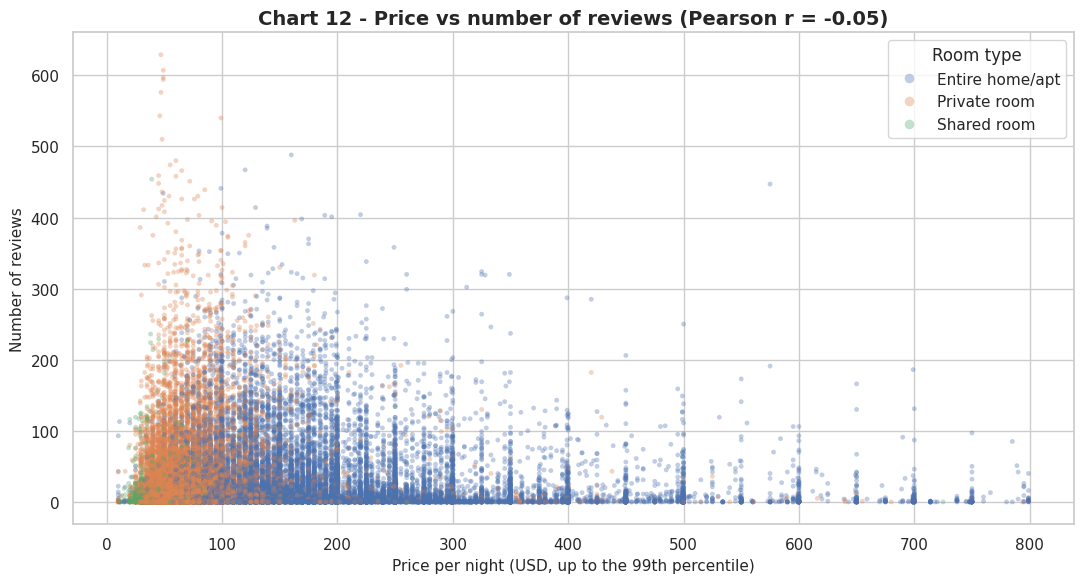

In [28]:
# Chart - 12 visualization code: price vs number of reviews (scatter, coloured by room type)
pearson_r = df["price"].corr(df["number_of_reviews"])
spearman_rho = df["price"].rank().corr(df["number_of_reviews"].rank())      # Spearman = Pearson on ranks
popular = df[df["number_of_reviews"] >= 100]
print(f"Pearson r = {pearson_r:.3f} | Spearman rho = {spearman_rho:.3f}")
print(f"Listings with 100+ reviews: {len(popular):,}, of which {popular['price'].lt(200).mean():.1%} cost under 200 USD")
print(f"Listings above 400 USD with more than 50 reviews: {df.loc[df['price'] > 400, 'number_of_reviews'].gt(50).mean():.1%}")

fig, ax = plt.subplots(figsize=(11, 6))
sns.scatterplot(data=dfp, x="price", y="number_of_reviews", hue="room_type", hue_order=ROOM_ORDER,
                palette=ROOM_COLORS, alpha=0.35, s=12, linewidth=0, ax=ax)
ax.legend(title="Room type", markerscale=2)
finish(ax, f"Chart 12 - Price vs number of reviews (Pearson r = {pearson_r:.2f})",
       "Price per night (USD, up to the 99th percentile)", "Number of reviews")

##### 1. Why did you pick this chart?
A scatter plot is the standard way to inspect the relationship between two numeric variables. Colouring by room type adds context, and transparency handles 48,000 overlapping points.

##### 2. What insights did you find?
There is **no meaningful linear relationship** (Pearson r = −0.05, Spearman ρ = −0.06). Heavily reviewed listings cluster at lower prices: **88.2%** of the 3,044 listings with 100+ reviews cost under \$200, while only **6.6%** of listings above \$400 have more than 50 reviews.

##### 3. How will these insights impact the business (positive or negative)?
- **Positive:** Guests reward value. Moderately priced listings earn the most reviews (bookings), so hosts can grow volume with competitive prices.
- **Negative:** Raising prices does not attract more guests. Expensive listings with few reviews risk long vacancies unless they offer clear extra quality.

#### Chart - 13 - Minimum nights vs reviews per month
*Bivariate – numerical vs numerical*

Spearman rho, minimum_nights vs reviews_per_month (all listings): -0.247


,listings,avg_reviews_per_month
minimum_nights,,
1,12717,1.60
2,11693,1.41
3,7998,1.04
5,3033,0.64
7,2058,0.39
14,562,0.32
30,3758,0.30


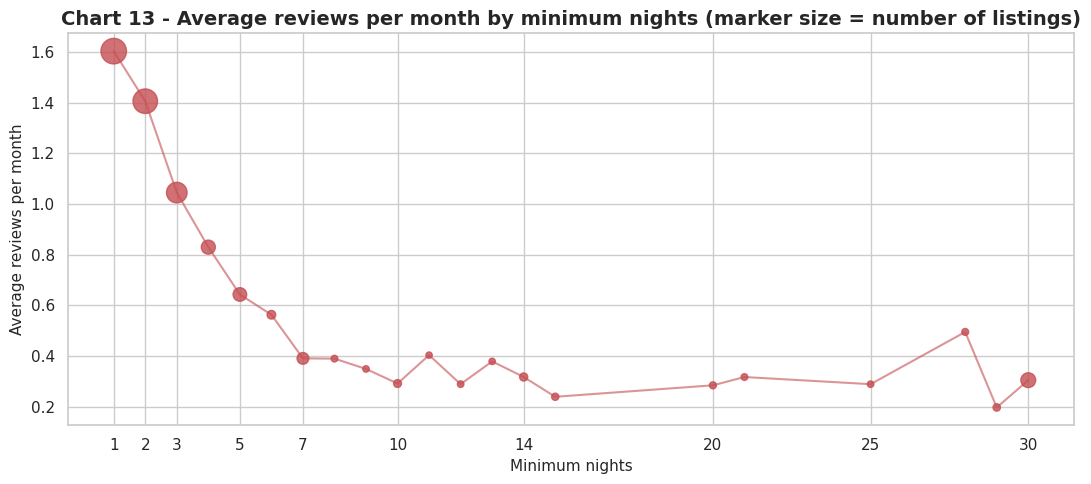

In [29]:
# Chart - 13 visualization code: does a longer minimum stay reduce booking frequency?
nights_rate = (df[df["minimum_nights"] <= 30]
               .groupby("minimum_nights")
               .agg(listings=("id", "size"), avg_reviews_per_month=("reviews_per_month", "mean")))
nights_rate = nights_rate[nights_rate["listings"] >= 30]       # keep values with enough listings for a stable average
rho = df["minimum_nights"].rank().corr(df["reviews_per_month"].rank())
print(f"Spearman rho, minimum_nights vs reviews_per_month (all listings): {rho:.3f}")
display(nights_rate[nights_rate.index.isin([1, 2, 3, 5, 7, 14, 30])].round(2))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(nights_rate.index, nights_rate["avg_reviews_per_month"], color="#C44E52", lw=1.5, alpha=0.6)
ax.scatter(nights_rate.index, nights_rate["avg_reviews_per_month"], s=20 + nights_rate["listings"] / 40,
           color="#C44E52", alpha=0.8, zorder=3)
ax.set_xticks([1, 2, 3, 5, 7, 10, 14, 20, 25, 30])
finish(ax, "Chart 13 - Average reviews per month by minimum nights (marker size = number of listings)",
       "Minimum nights", "Average reviews per month")

##### 1. Why did you pick this chart?
Both variables are numeric. Plotting the average review rate for each minimum-night value (1–30, values with at least 30 listings; marker size shows how many listings) shows the trend far more clearly than a cloud of 48,000 points.

##### 2. What insights did you find?
The review rate **falls steadily as the minimum stay rises**: 1.60 reviews/month for a 1-night minimum, 1.41 for 2 nights, 1.04 for 3, 0.39 for 7 and **0.30 for 30 nights** (Spearman ρ = −0.25 across all listings).

##### 3. How will these insights impact the business (positive or negative)?
- **Positive:** Hosts can raise booking frequency, and collect the reviews that drive future bookings, by lowering minimum stays where the law allows (for example, host-present private rooms).
- **Negative:** Long minimum stays cut turnover and review flow. Listings that need 30+ nights add little to tourist demand and build social proof slowly.

#### Chart - 14 - Room-type mix within each borough
*Bivariate – categorical vs categorical*

room_type,Entire home/apt,Private room,Shared room
neighbourhood_group,,,
Manhattan,60.90,36.90,2.20
Brooklyn,47.60,50.40,2.00
Queens,37.00,59.50,3.50
Bronx,34.80,59.70,5.50
Staten Island,47.20,50.40,2.40


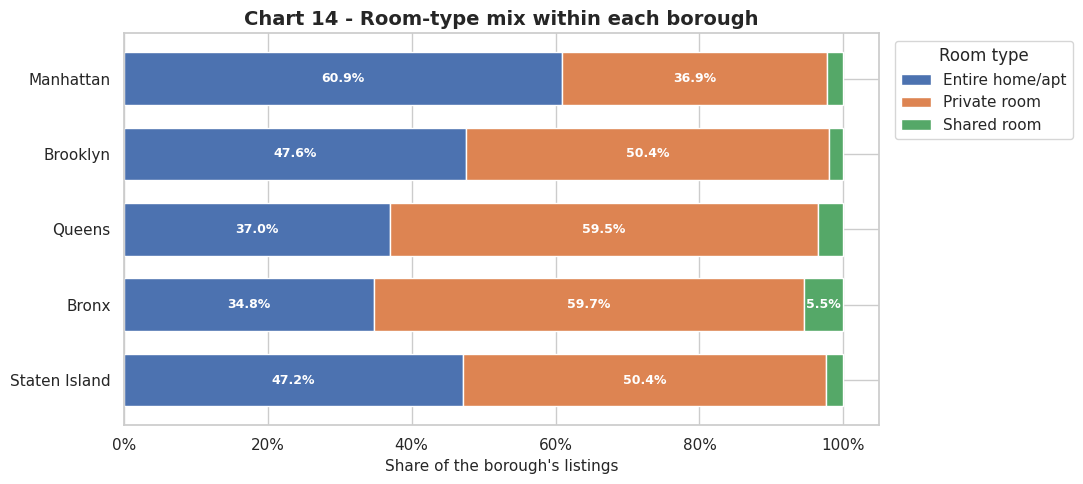

In [30]:
# Chart - 14 visualization code: room-type mix inside each borough (100% stacked bars)
room_mix = (pd.crosstab(df["neighbourhood_group"], df["room_type"], normalize="index") * 100
            ).reindex(index=BOROUGH_ORDER, columns=ROOM_ORDER)
display(room_mix.round(1))

ax = room_mix.plot(kind="barh", stacked=True, figsize=(11, 5), color=[ROOM_COLORS[r] for r in ROOM_ORDER], width=0.7)
for container in ax.containers:
    ax.bar_label(container, labels=[f"{v:.1f}%" if v >= 4 else "" for v in container.datavalues],
                 label_type="center", color="white", fontweight="bold", fontsize=9)
ax.invert_yaxis()                                     # largest borough on top
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title="Room type", bbox_to_anchor=(1.01, 1), loc="upper left")
finish(ax, "Chart 14 - Room-type mix within each borough", "Share of the borough's listings", "")

##### 1. Why did you pick this chart?
Borough and room type are both categorical. A 100% stacked bar compares the room-type mix across boroughs regardless of their very different sizes.

##### 2. What insights did you find?
**Manhattan is the only borough dominated by entire homes (60.9%).** Brooklyn is balanced (47.6% entire, 50.4% private), while Queens (59.5%) and the Bronx (59.7%) are mostly private rooms. Shared rooms are rare everywhere but most common in the Bronx (5.5%).

##### 3. How will these insights impact the business (positive or negative)?
- **Positive:** The outer boroughs offer affordable private rooms that suit budget travellers, students and airport stopovers, while Manhattan suits families and business travellers. Marketing can be segmented accordingly.
- **Negative:** Manhattan's entire-home-heavy supply is the segment most exposed to New York's restriction on renting an entire home for under 30 days. Tighter enforcement would hit the highest-revenue listings.

#### Chart - 15 - Minimum-stay policy by host portfolio size
*Bivariate – categorical vs categorical*

stay_type,Short stay (<30 nights),Long stay (30+ nights)
host_portfolio,,
1,95.50,4.50
2,94.80,5.20
3-5,91.40,8.60
6-10,75.40,24.60
11+,39.40,60.60


,listings,long_stay_pct,median_days_available,median_price,entire_home_pct
host_type,,,,,
Multi-listing host,16582,18.30,179.00,93.00,38.70
Single-listing host,32288,4.50,6.00,119.00,58.80


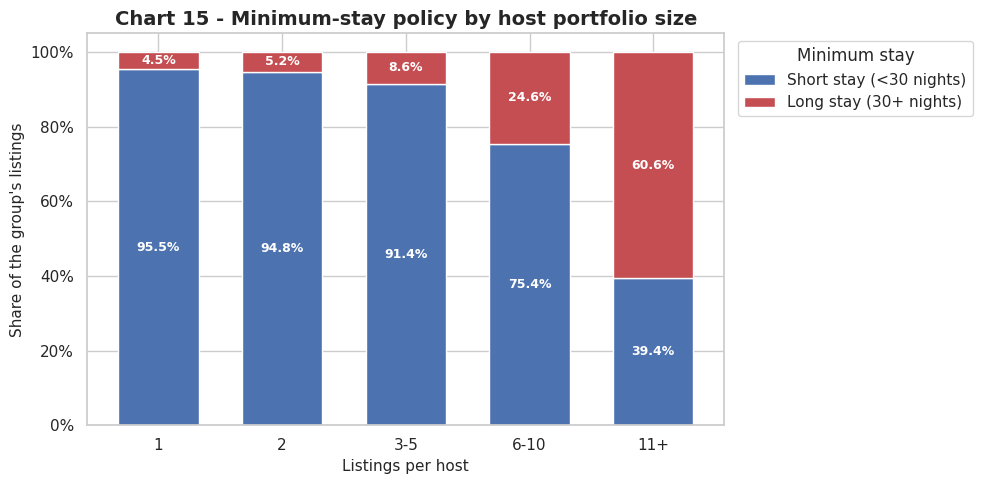

In [31]:
# Chart - 15 visualization code: short vs long minimum stays by host portfolio size (100% stacked bars)
STAY_ORDER = ["Short stay (<30 nights)", "Long stay (30+ nights)"]
stay_mix = (pd.crosstab(df["host_portfolio"], df["stay_type"], normalize="index") * 100).reindex(columns=STAY_ORDER)
display(stay_mix.round(1))
display(df.groupby("host_type").agg(
    listings=("id", "size"),
    long_stay_pct=("stay_type", lambda s: s.eq("Long stay (30+ nights)").mean() * 100),
    median_days_available=("availability_365", "median"),
    median_price=("price", "median"),
    entire_home_pct=("room_type", lambda s: s.eq("Entire home/apt").mean() * 100)).round(1))

ax = stay_mix.plot(kind="bar", stacked=True, figsize=(10, 5), color=["#4C72B0", "#C44E52"], rot=0, width=0.65)
for container in ax.containers:
    ax.bar_label(container, labels=[f"{v:.1f}%" if v >= 3 else "" for v in container.datavalues],
                 label_type="center", color="white", fontweight="bold", fontsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title="Minimum stay", bbox_to_anchor=(1.01, 1), loc="upper left")
finish(ax, "Chart 15 - Minimum-stay policy by host portfolio size", "Listings per host", "Share of the group's listings")

##### 1. Why did you pick this chart?
Host portfolio size and stay type are both categorical. A 100% stacked bar shows how the minimum-stay policy shifts as hosts get bigger.

##### 2. What insights did you find?
Only **4.5%** of single-listing hosts' listings require 30+ nights, rising to 8.6% for hosts with 3–5 listings, 24.6% for 6–10 and **60.6% for 11+**. Across all multi-listing hosts the share is 18.3%. They also keep listings open far longer (median **179 vs 6 days** a year) and price lower (median \$93 vs \$119), because many of them run private rooms.

##### 3. How will these insights impact the business (positive or negative)?
- **Positive:** Large operators supply dependable monthly stays for relocation and corporate travel, a niche that hotels serve poorly.
- **Negative:** This is commercial furnished-rental behaviour on a home-sharing platform. It is often criticised for taking homes off the long-term rental market, it invites regulatory action, and it removes these listings from the short-stay pool that tourists search.

#### Chart - 16 - Most expensive neighbourhoods
*Bivariate – numerical vs categorical*

,median_price,listings,borough
neighbourhood,,,
Tribeca,295.00,177,Manhattan
NoHo,250.00,78,Manhattan
Flatiron District,225.00,80,Manhattan
Midtown,210.00,1544,Manhattan
Financial District,200.00,744,Manhattan
West Village,200.00,768,Manhattan
Chelsea,199.00,1113,Manhattan
SoHo,199.00,358,Manhattan
Greenwich Village,198.50,390,Manhattan


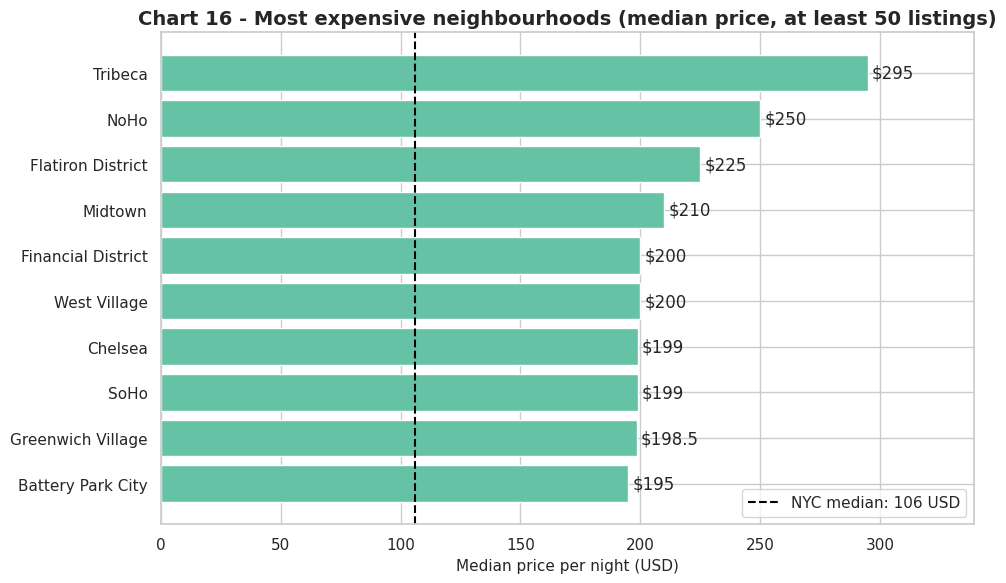

In [32]:
# Chart - 16 visualization code: most expensive neighbourhoods (median price, at least 50 listings)
MIN_LISTINGS = 50                                     # ignore tiny neighbourhoods whose median is unstable
nbhd_price = df.groupby("neighbourhood").agg(median_price=("price", "median"), listings=("id", "size"),
                                             borough=("neighbourhood_group", "first"))
top_price = nbhd_price[nbhd_price["listings"] >= MIN_LISTINGS].nlargest(10, "median_price")
display(top_price)

plot_data = top_price.iloc[::-1]                      # most expensive at the top
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(plot_data.index, plot_data["median_price"], color=[BOROUGH_COLORS[b] for b in plot_data["borough"]])
ax.bar_label(bars, labels=[usd(v) for v in plot_data["median_price"]], padding=3)
ax.axvline(df["price"].median(), color="black", ls="--", lw=1.5, label=f"NYC median: {df['price'].median():,.0f} USD")
ax.legend(loc="lower right")
ax.set_xlim(0, plot_data["median_price"].max() * 1.15)
finish(ax, f"Chart 16 - Most expensive neighbourhoods (median price, at least {MIN_LISTINGS} listings)",
       "Median price per night (USD)", "")

##### 1. Why did you pick this chart?
Ranking neighbourhoods by median price shows where premium demand lies. Only neighbourhoods with at least 50 listings are included, to avoid noisy small samples, and the dashed line marks the NYC median for reference.

##### 2. What insights did you find?
**All ten are in Manhattan**: Tribeca (\$295), NoHo (\$250), Flatiron District (\$225), Midtown (\$210), Financial District and West Village (\$200), SoHo and Chelsea (\$199), Greenwich Village (\$198.5) and Battery Park City (\$195). That is roughly **2–3× the NYC median of \$106**.

##### 3. How will these insights impact the business (positive or negative)?
- **Positive:** These neighbourhoods are the premium segment for luxury and business travel, and the natural place for high-end offerings and partnerships.
- **Negative:** Premium listings compete head-on with hotels and need quality to justify their price, otherwise they sit empty. Listings at \$500+ get the fewest reviews and have the most unsold days (Chart 19).

#### Chart - 17 - Availability by room type
*Bivariate – numerical vs categorical*

,median,mean,zero_days_pct
room_type,,,
Entire home/apt,42.00,111.90,34.90
Private room,45.00,111.20,37.50
Shared room,90.00,161.70,25.60


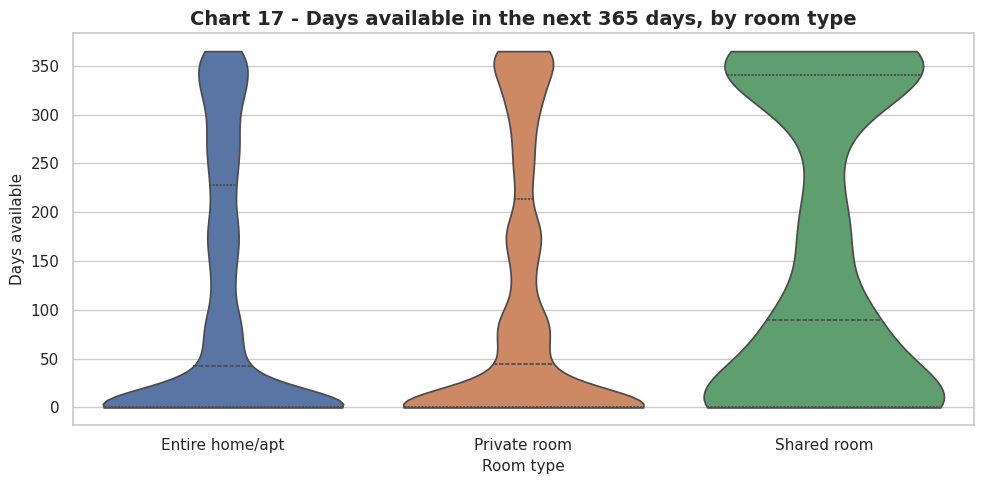

In [33]:
# Chart - 17 visualization code: availability over the next 365 days by room type (violin plot)
room_avail = df.groupby("room_type")["availability_365"].agg(
    median="median", mean="mean", zero_days_pct=lambda s: s.eq(0).mean() * 100).reindex(ROOM_ORDER)
display(room_avail.round(1))

fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(data=df, x="room_type", y="availability_365", order=ROOM_ORDER, hue="room_type", hue_order=ROOM_ORDER,
               palette=ROOM_COLORS, cut=0, inner="quartile", legend=False, ax=ax)
finish(ax, "Chart 17 - Days available in the next 365 days, by room type", "Room type", "Days available")

##### 1. Why did you pick this chart?
A violin plot shows the whole distribution shape for each category. That matters here because availability is bimodal (0 days vs nearly 365), which an average would hide.

##### 2. What insights did you find?
Entire homes and private rooms look alike (median 42 and 45 days, mean about 112), each with a large cluster at 0 days (34.9% and 37.5% of listings). **Shared rooms are much more available** (median 90 days, mean 162), and fewer of them (25.6%) are fully blocked.

##### 3. How will these insights impact the business (positive or negative)?
- **Positive:** Shared rooms have spare capacity that Airbnb could fill with budget and backpacker promotions.
- **Negative:** The high availability of shared rooms more likely reflects weak demand than generous hosting, since they also get the fewest reviews. The zero-availability cluster in every room type means a big part of the inventory cannot be booked.

#### Chart - 18 - Guest activity (reviews) by borough
*Bivariate – numerical vs categorical*

,listings_share_%,reviews_share_%,median_reviews_per_month,avg_reviews_per_listing,long_stay_share_%
neighbourhood_group,,,,,
Staten Island,0.76,1.01,1.41,30.94,5.09
Bronx,2.23,2.49,1.38,25.98,3.49
Queens,11.59,13.79,1.21,27.70,6.34
Brooklyn,41.11,42.74,0.66,24.20,6.27
Manhattan,44.31,39.96,0.61,20.99,13.00


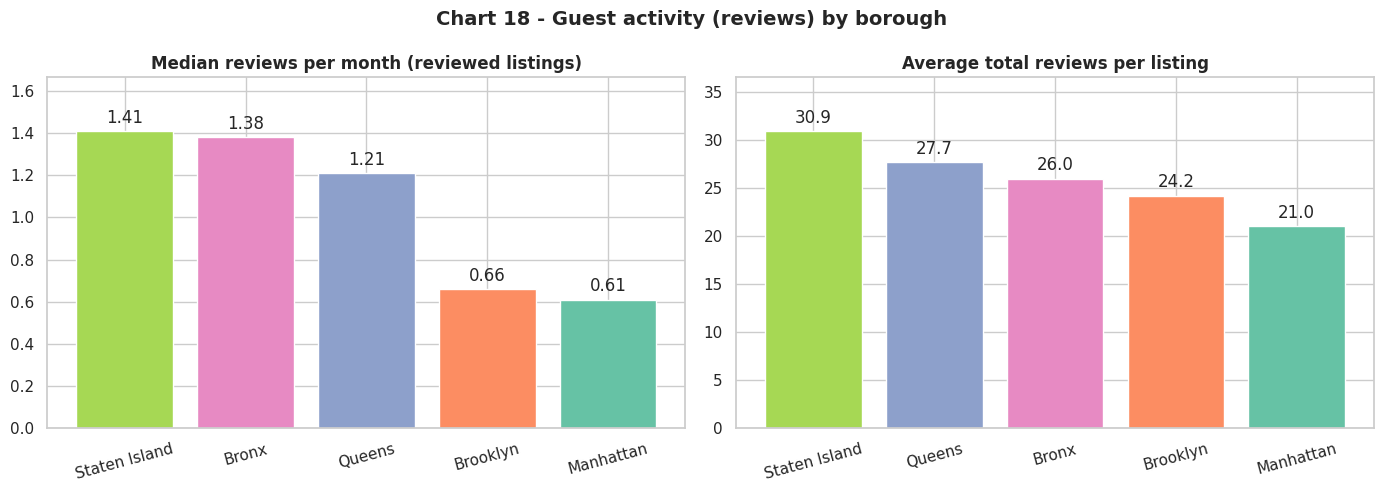

In [34]:
# Chart - 18 visualization code: review activity by borough (traffic per listing)
reviewed = df[df["has_reviews"]]
borough_activity = pd.DataFrame({
    "listings_share_%": df["neighbourhood_group"].value_counts(normalize=True) * 100,
    "reviews_share_%": df.groupby("neighbourhood_group")["number_of_reviews"].sum() / df["number_of_reviews"].sum() * 100,
    "median_reviews_per_month": reviewed.groupby("neighbourhood_group")["reviews_per_month"].median(),
    "avg_reviews_per_listing": df.groupby("neighbourhood_group")["number_of_reviews"].mean(),
    "long_stay_share_%": df.groupby("neighbourhood_group")["minimum_nights"].apply(lambda s: s.ge(30).mean() * 100),
}).sort_values("median_reviews_per_month", ascending=False)
display(borough_activity.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
panels = [("median_reviews_per_month", "Median reviews per month (reviewed listings)", "{:.2f}"),
          ("avg_reviews_per_listing", "Average total reviews per listing", "{:.1f}")]
for ax, (col, title, fmt) in zip(axes, panels):
    data = borough_activity[col].sort_values(ascending=False)
    bars = ax.bar(data.index, data.values, color=[BOROUGH_COLORS[b] for b in data.index])
    ax.bar_label(bars, labels=[fmt.format(v) for v in data.values], padding=3)
    ax.set_title(title, fontsize=12)
    ax.set_ylim(0, data.max() * 1.18)
    ax.tick_params(axis="x", rotation=15)
fig.suptitle("Chart 18 - Guest activity (reviews) by borough", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

##### 1. Why did you pick this chart?
Reviews are the best proxy for bookings in this dataset. Comparing the review rate and reviews per listing across boroughs answers the question "is there a difference in traffic between areas?"

##### 2. What insights did you find?
Traffic per listing is the **reverse of supply**. Staten Island (1.41 reviews/month), the Bronx (1.38) and Queens (1.21) have **about twice the review rate** of Brooklyn (0.66) and Manhattan (0.61), counting reviewed listings only. Average reviews per listing show the same pattern: Staten Island (30.9), Queens (27.7) and the Bronx (26.0) lead, while Brooklyn (24.2) and Manhattan (21.0) trail. Manhattan holds 44.3% of listings but only 40.0% of all reviews, while Queens holds 11.6% of listings and 13.8% of reviews.

Likely reasons: lower prices, more private rooms, fewer 30-night minimums (13.0% of listings in Manhattan against 3.5–6.3% elsewhere), the two airports in Queens, and less competition per listing.

##### 3. How will these insights impact the business (positive or negative)?
- **Positive:** Outer-borough listings turn over faster: demand is healthy and supply is thin, a clear growth opportunity. Airbnb can recruit hosts there and promote budget and airport-adjacent stays.
- **Negative:** Manhattan listings compete for the same guests, so bookings per listing are lower. Adding more Manhattan supply would dilute host earnings further.

#### Chart - 19 - Demand and unsold days by price band
*Bivariate – numerical vs categorical (ordered)*

,listings,avg_reviews,never_reviewed_pct,avg_days_available
price_band,,,,
Budget (<$100),21860,24.80,18.30,105.60
Mid ($100-199),17227,25.30,18.50,105.40
Premium ($200-499),8548,17.00,27.70,135.90
Luxury ($500+),1235,10.90,40.40,180.80


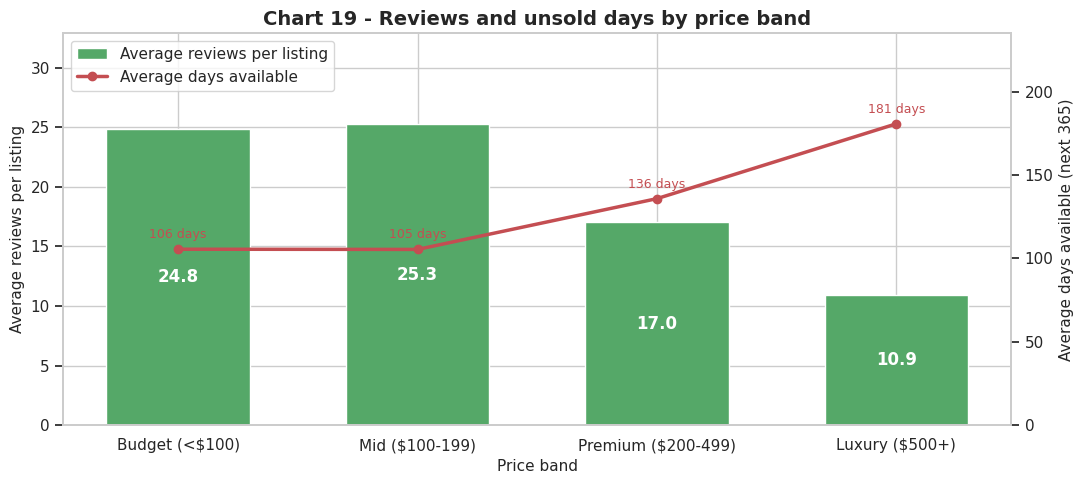

In [35]:
# Chart - 19 visualization code: average reviews (bars) and average days available (line) by price band
band_demand = df.groupby("price_band", observed=True).agg(
    listings=("id", "size"),
    avg_reviews=("number_of_reviews", "mean"),
    never_reviewed_pct=("number_of_reviews", lambda s: s.eq(0).mean() * 100),
    avg_days_available=("availability_365", "mean"))
display(band_demand.round(1))

x = np.arange(len(band_demand))
fig, ax1 = plt.subplots(figsize=(11, 5))
bars = ax1.bar(x, band_demand["avg_reviews"], color="#55A868", width=0.6, label="Average reviews per listing")
ax1.bar_label(bars, labels=[f"{v:.1f}" for v in band_demand["avg_reviews"]], label_type="center",
               color="white", fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(band_demand.index.astype(str))
ax1.set_ylabel("Average reviews per listing")
ax1.set_ylim(0, band_demand["avg_reviews"].max() * 1.3)

ax2 = ax1.twinx()                                     # second y-axis for availability
ax2.plot(x, band_demand["avg_days_available"], color="#C44E52", marker="o", lw=2.5, label="Average days available")
for xi, yi in zip(x, band_demand["avg_days_available"]):
    ax2.annotate(f"{yi:.0f} days", (xi, yi), textcoords="offset points", xytext=(0, 8), ha="center",
                 color="#C44E52", fontsize=9)
ax2.set_ylabel("Average days available (next 365)")
ax2.set_ylim(0, band_demand["avg_days_available"].max() * 1.3)
ax2.grid(False)
ax1.legend(handles=[bars, ax2.lines[0]], loc="upper left")
finish(ax1, "Chart 19 - Reviews and unsold days by price band", "Price band", None)

##### 1. Why did you pick this chart?
A combined bar-and-line chart puts demand (average reviews) and unsold capacity (average days available) side by side across the ordered price bands, showing how both move as price rises.

##### 2. What insights did you find?
Budget (<\$100) and Mid (\$100–199) listings average **about 25 reviews**, Premium (\$200–499) 17.0 and Luxury (\$500+) **just 10.9**. Average availability rises from about 105 days to **181 days**, and **40.4%** of luxury listings have never been reviewed, against 18.3% of budget listings.

##### 3. How will these insights impact the business (positive or negative)?
- **Positive:** Demand is strongest below \$200, the core of the market, so Airbnb should keep acquiring good-value supply there.
- **Negative:** Luxury listings stay empty longer and convert poorly. Their hosts need pricing guidance or stronger quality signals (photos, amenities, professional cleaning), or they will keep losing income.

#### Chart - 20 - Biggest vs busiest hosts
*Bivariate – numerical vs categorical*

,host_name,listings,total_reviews,main_borough,main_neighbourhood,main_room_type,median_price,median_min_nights
34631,Sonder (NYC),327,1281,Manhattan,Financial District,Entire home/apt,228.00,2.00
29393,Blueground,232,29,Manhattan,Chelsea,Entire home/apt,302.50,30.00
19562,Kara,121,65,Manhattan,Hell's Kitchen,Entire home/apt,239.00,30.00
31065,Kazuya,103,87,Queens,Woodside,Private room,41.00,30.00
12798,Sonder,96,43,Manhattan,Financial District,Entire home/apt,209.50,29.00
14426,Jeremy & Laura,96,138,Manhattan,Midtown,Entire home/apt,180.00,30.00
25649,Corporate Housing,91,417,Manhattan,Kips Bay,Entire home/apt,142.00,30.00
17079,Ken,87,55,Manhattan,Chelsea,Entire home/apt,210.00,30.00
33854,Pranjal,65,1,Manhattan,Midtown,Entire home/apt,250.00,30.00
3044,Mike,52,162,Manhattan,Midtown,Entire home/apt,96.00,30.00


,host_name,listings,total_reviews,main_borough,main_neighbourhood,main_room_type,median_price,median_min_nights
21304,Maya,5,2273,Queens,East Elmhurst,Private room,45.00,1.00
1052,Brooklyn& Breakfast -Len-,13,2205,Brooklyn,Prospect Heights,Private room,60.00,1.00
18624,Danielle,5,2017,Queens,East Elmhurst,Private room,48.00,1.00
20872,Yasu & Akiko,11,1971,Manhattan,Hell's Kitchen,Private room,155.00,1.00
21922,Brady,7,1818,Brooklyn,Bedford-Stuyvesant,Private room,79.00,1.00
7361,Jj,3,1798,Manhattan,Harlem,Private room,49.00,1.00
14703,Alex And Zeena,12,1355,Manhattan,Chelsea,Private room,85.00,1.00
9201,Randy,15,1346,Brooklyn,Bedford-Stuyvesant,Private room,55.00,1.00
34631,Sonder (NYC),327,1281,Manhattan,Financial District,Entire home/apt,228.00,2.00
17513,Angela,4,1269,Queens,East Elmhurst,Private room,65.00,1.00


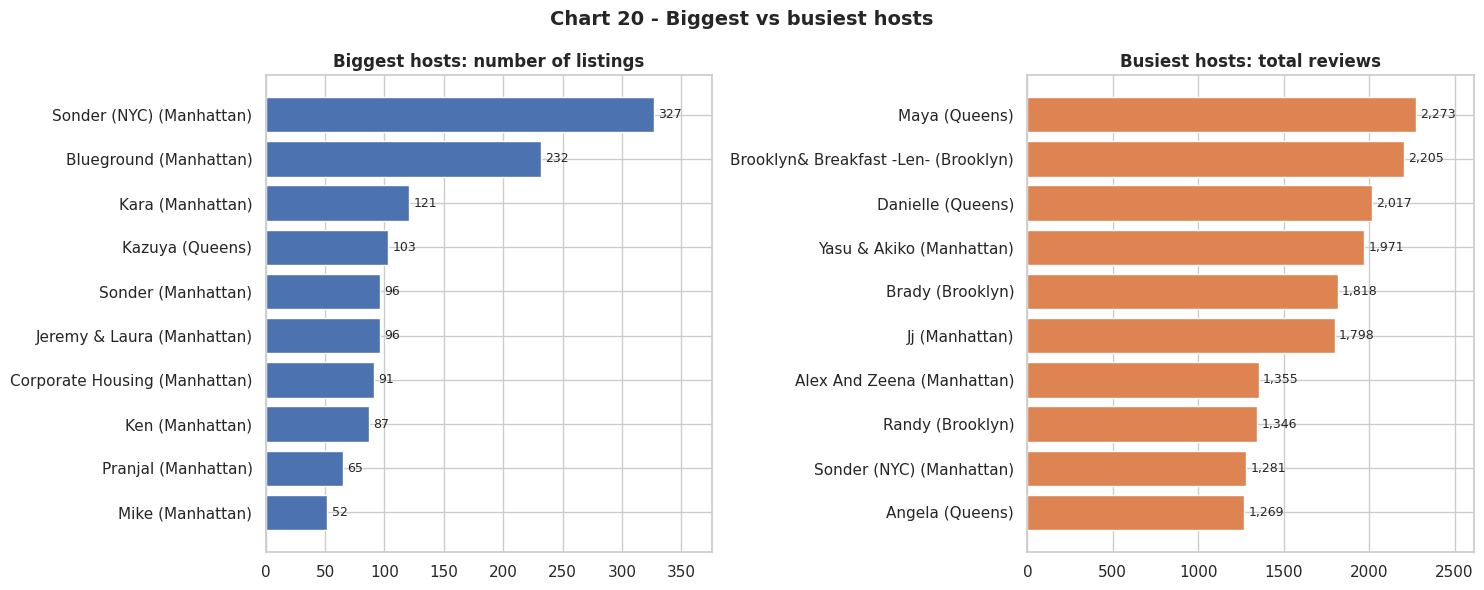

In [36]:
# Chart - 20 visualization code: biggest hosts (most listings) vs busiest hosts (most reviews)
def main_value(s):
    """Most frequent value of a column within a group."""
    return s.mode().iat[0]


host_summary = (df.groupby(["host_id", "host_name"])
                  .agg(listings=("id", "size"), total_reviews=("number_of_reviews", "sum"),
                       main_borough=("neighbourhood_group", main_value),
                       main_neighbourhood=("neighbourhood", main_value),
                       main_room_type=("room_type", main_value), median_price=("price", "median"),
                       median_min_nights=("minimum_nights", "median"))
                  .reset_index())
top_by_listings = host_summary.nlargest(10, "listings")
top_by_reviews = host_summary.nlargest(10, "total_reviews")
display(top_by_listings.drop(columns="host_id"))
display(top_by_reviews.drop(columns="host_id"))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
panels = [(axes[0], top_by_listings, "listings", "Biggest hosts: number of listings", "#4C72B0"),
          (axes[1], top_by_reviews, "total_reviews", "Busiest hosts: total reviews", "#DD8452")]
for ax, data, col, title, color in panels:
    data = data.iloc[::-1]                            # largest at the top
    y = np.arange(len(data))
    bars = ax.barh(y, data[col], color=color)
    ax.bar_label(bars, labels=[f"{v:,}" for v in data[col]], padding=3, fontsize=9)
    ax.set_yticks(y)
    ax.set_yticklabels(data["host_name"] + " (" + data["main_borough"] + ")")
    ax.set_title(title, fontsize=12)
    ax.set_xlim(0, data[col].max() * 1.15)
fig.suptitle("Chart 20 - Biggest vs busiest hosts", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

##### 1. Why did you pick this chart?
Two ranked horizontal bar charts answer "who are the biggest hosts, and who are the busiest?" Putting them side by side shows that size (listings) and activity (reviews) are different things.

##### 2. What insights did you find?
**The biggest hosts are companies.** Sonder (NYC) has 327 listings and Blueground 232, followed by Kara (121) and Kazuya (103). Nine of the top ten run entire apartments in Manhattan, and eight have a median minimum stay of 30 nights. Blueground's 232 listings have **only 29 reviews** in total.

**The busiest hosts are small.** Maya (5 listings, 2,273 reviews), Brooklyn& Breakfast -Len- (13; 2,205) and Danielle (5; 2,017) lead. Nine of the ten busiest mainly rent **private rooms with a 1-night minimum**, eight of them at a median price of \$45–85. Three (Maya, Danielle and Angela) are in East Elmhurst, Queens, **next to LaGuardia Airport**. Others are in Bedford-Stuyvesant, Prospect Heights, Harlem, Hell's Kitchen and Chelsea, all well connected by subway.

##### 3. How will these insights impact the business (positive or negative)?
- **Positive:** The busiest hosts show a repeatable formula: a low price, a private room, a 1-night minimum and good transport links. Airbnb can teach it to other hosts and reward it with visibility.
- **Negative:** The largest operators add many listings but few reviews (they mostly rent by the month). They add supply without adding much short-stay activity, while carrying the most regulatory risk.

### **4.3 Multivariate Analysis**

#### Chart - 21 - Listing locations by borough
*Multivariate – latitude × longitude × borough*

Queens: Astoria (900), Long Island City (535), Flushing (426), Ridgewood (423)
Bronx: Kingsbridge (70), Fordham (63), Longwood (62), Mott Haven (60)
Staten Island: St. George (48), Tompkinsville (42), Stapleton (27), Concord (26)


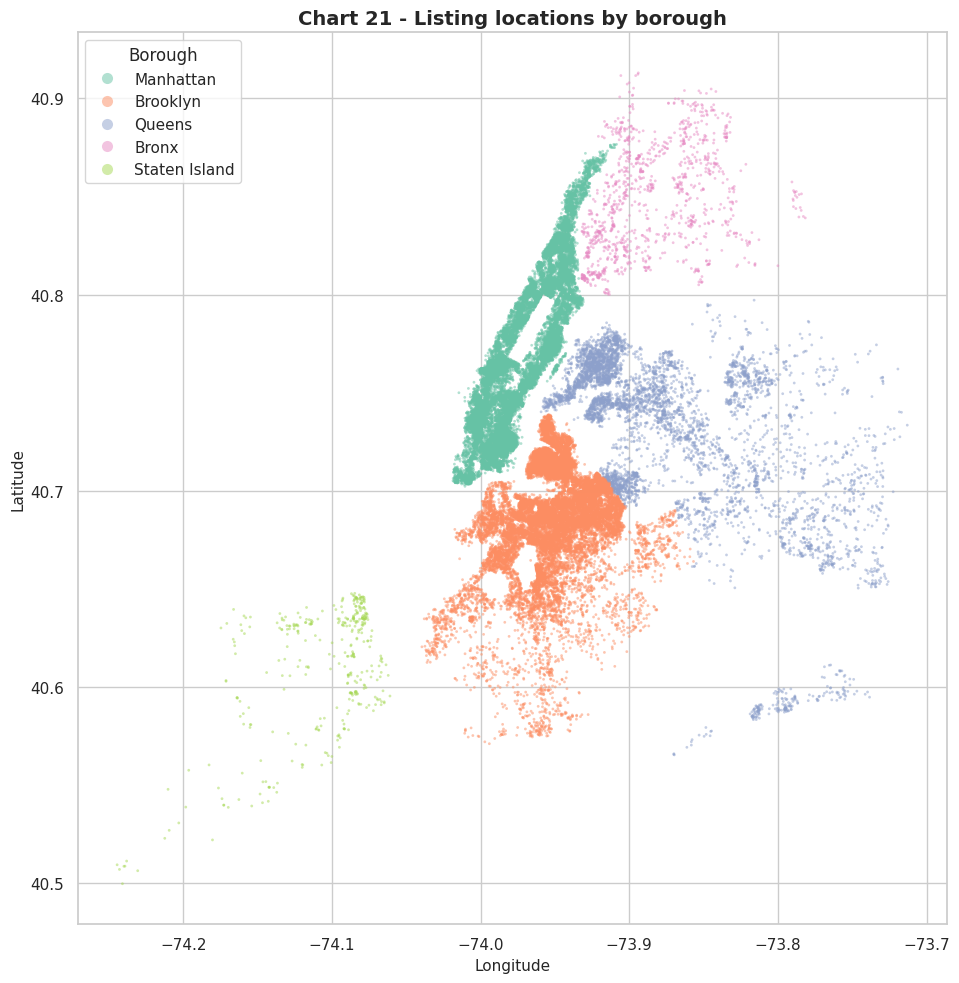

In [37]:
# Chart - 21 visualization code: where the listings are (longitude vs latitude, coloured by borough)
for borough in ["Queens", "Bronx", "Staten Island"]:
    top_areas = df.loc[df["neighbourhood_group"] == borough, "neighbourhood"].value_counts().head(4)
    print(f"{borough}: " + ", ".join(f"{n} ({c})" for n, c in top_areas.items()))

fig, ax = plt.subplots(figsize=(10, 10))
sns.scatterplot(data=df, x="longitude", y="latitude", hue="neighbourhood_group", hue_order=BOROUGH_ORDER,
                palette=BOROUGH_COLORS, s=4, alpha=0.5, linewidth=0, ax=ax)
ax.set_aspect(1 / np.cos(np.radians(df["latitude"].mean())))    # correct the east-west stretch at NYC's latitude
ax.legend(title="Borough", markerscale=4, loc="upper left")
finish(ax, "Chart 21 - Listing locations by borough", "Longitude", "Latitude")

##### 1. Why did you pick this chart?
Plotting longitude against latitude turns the data into a map. Colouring by borough adds a third variable and shows the geographic footprint of supply.

##### 2. What insights did you find?
Listings form one dense mass from the southern tip of Manhattan up through Harlem and across the East River into north and central Brooklyn (Williamsburg, Bedford-Stuyvesant, Bushwick), thinning out towards south Brooklyn. Queens listings are spread more widely: the densest pockets sit next to Manhattan and Brooklyn (Astoria, Long Island City, Ridgewood), with another in Flushing and a small group on the Rockaway peninsula. The Bronx is sparse, and Staten Island's largest groups are around St. George, Tompkinsville and Stapleton on the north shore, near the Manhattan ferry.

##### 3. How will these insights impact the business (positive or negative)?
- **Positive:** The map shows exactly where supply is thin relative to the city's footprint, which gives target areas for host acquisition.
- **Negative:** Dense clusters face local saturation and neighbourhood pushback, while sparse areas give guests little choice and few reviews to rely on.

#### Chart - 22 - Listing locations coloured by price
*Multivariate – latitude × longitude × price*

Manhattan median price: north of Central Park 85 USD | further south 165 USD
Spearman rho, price vs longitude = -0.438 (negative: prices fall towards the east)


,median_price,listings
neighbourhood,,
DUMBO,189.00,36
Brooklyn Heights,150.00,154
Williamsburg,105.00,3917
Bedford-Stuyvesant,80.00,3709
Bushwick,65.00,2461


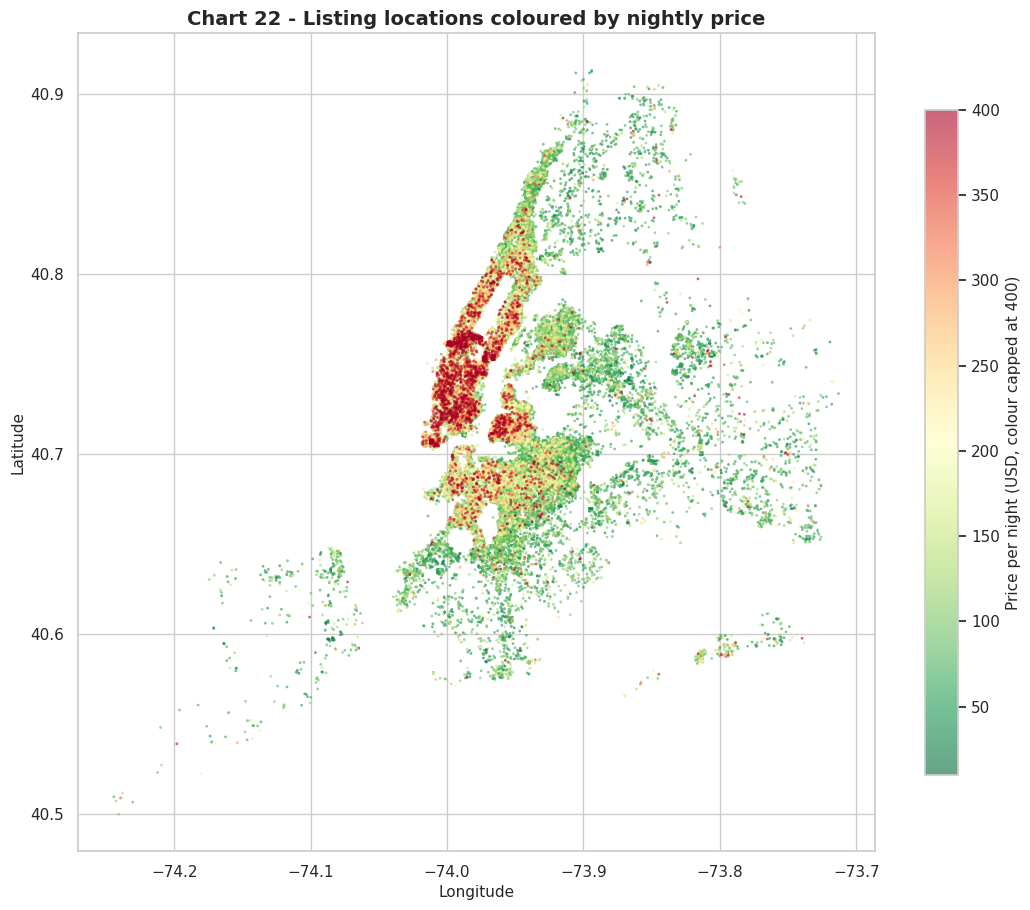

In [38]:
# Chart - 22 visualization code: where the expensive listings are (colour = nightly price)
map_df = dfp.sort_values("price")                    # draw expensive listings last so they stay visible
lon_rho = df["price"].rank().corr(df["longitude"].rank())
manhattan = df[df["neighbourhood_group"] == "Manhattan"]
north_of_park = manhattan["latitude"] > 40.80           # Central Park ends at about 40.80 degrees north
print(f"Manhattan median price: north of Central Park {manhattan.loc[north_of_park, 'price'].median():,.0f} USD | "
      f"further south {manhattan.loc[~north_of_park, 'price'].median():,.0f} USD")
print(f"Spearman rho, price vs longitude = {lon_rho:.3f} (negative: prices fall towards the east)")
display(df[df["neighbourhood"].isin(["DUMBO", "Brooklyn Heights", "Williamsburg", "Bedford-Stuyvesant", "Bushwick"])]
        .groupby("neighbourhood")["price"].agg(median_price="median", listings="size")
        .sort_values("median_price", ascending=False))

fig, ax = plt.subplots(figsize=(11, 10))
points = ax.scatter(map_df["longitude"], map_df["latitude"], c=map_df["price"].clip(upper=400),
                    cmap="RdYlGn_r", s=4, alpha=0.6, linewidths=0)
fig.colorbar(points, ax=ax, shrink=0.7, label="Price per night (USD, colour capped at 400)")
ax.set_aspect(1 / np.cos(np.radians(df["latitude"].mean())))
finish(ax, "Chart 22 - Listing locations coloured by nightly price", "Longitude", "Latitude")

##### 1. Why did you pick this chart?
Colouring the location map by price adds price as a third variable and shows how it changes across the city in one view.

##### 2. What insights did you find?
The most expensive listings (red) are concentrated in Manhattan south of Central Park's northern end: listings north of it have a median of \$85, against \$165 further south. The other hot spot is the Brooklyn waterfront facing Manhattan: DUMBO has a median of \$189 and Brooklyn Heights \$150, against \$90 for Brooklyn overall. Prices cool to green moving east into central Brooklyn (Bedford-Stuyvesant \$80, Bushwick \$65), Queens and the Bronx. The rank correlation between price and longitude is **−0.44**: the further east, the cheaper.

##### 3. How will these insights impact the business (positive or negative)?
- **Positive:** Proximity to Manhattan is the main price premium. Hosts near the river can price higher, and budget guests can be guided to cheaper, well-connected areas.
- **Negative:** Hosts far from Manhattan earn much less per night and must compete on occupancy and value. Airbnb's pricing guidance has to be location-aware so it doesn't push them into over-pricing.

#### Chart - 23 - Median price by borough and room type
*Multivariate – borough × room type × price*

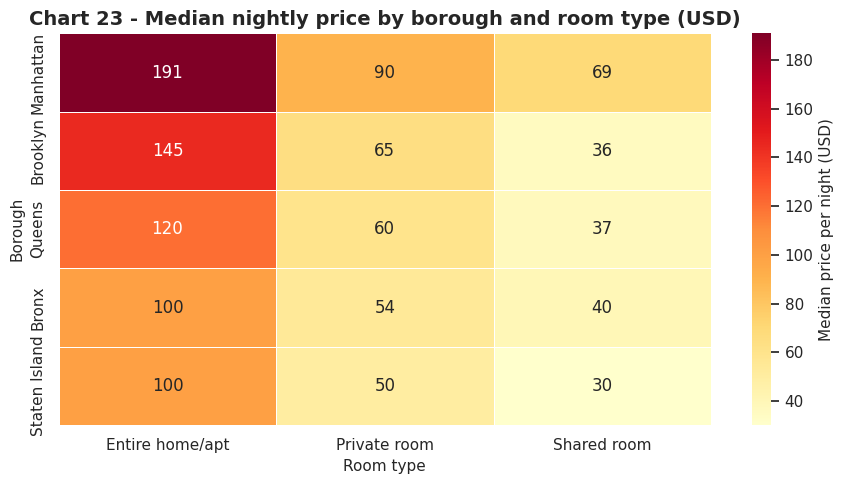

In [39]:
# Chart - 23 visualization code: median price for every borough x room-type combination
price_matrix = (df.pivot_table(index="neighbourhood_group", columns="room_type", values="price", aggfunc="median")
                  .reindex(index=BOROUGH_ORDER, columns=ROOM_ORDER))
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(price_matrix, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5,
            cbar_kws={"label": "Median price per night (USD)"}, ax=ax)
finish(ax, "Chart 23 - Median nightly price by borough and room type (USD)", "Room type", "Borough")

##### 1. Why did you pick this chart?
A heatmap shows a numeric value (median price) for every combination of two categorical variables, so their joint effect is visible at a glance.

##### 2. What insights did you find?
Median prices for entire home / private room / shared room are: Manhattan **\$191 / \$90 / \$69**; Brooklyn \$145 / \$65 / \$36; Queens \$120 / \$60 / \$37; Bronx \$100 / \$54 / \$40; Staten Island \$100 / \$50 / \$30. The room-type effect holds in every borough (an entire home costs about 2× a private room), and the borough effect holds for every room type. **A Manhattan private room (\$90) costs about the same as an entire home in the Bronx or Staten Island (\$100).**

##### 3. How will these insights impact the business (positive or negative)?
- **Positive:** This simple two-factor grid is a strong baseline for a host price-suggestion tool and for spotting mis-priced listings.
- **Negative:** Listings priced far above their cell (say, a \$500 private room in Queens) will struggle to get booked, and those far below may be under-earning.

#### Chart - 24 - Correlation heatmap
*Multivariate – all numeric variables*

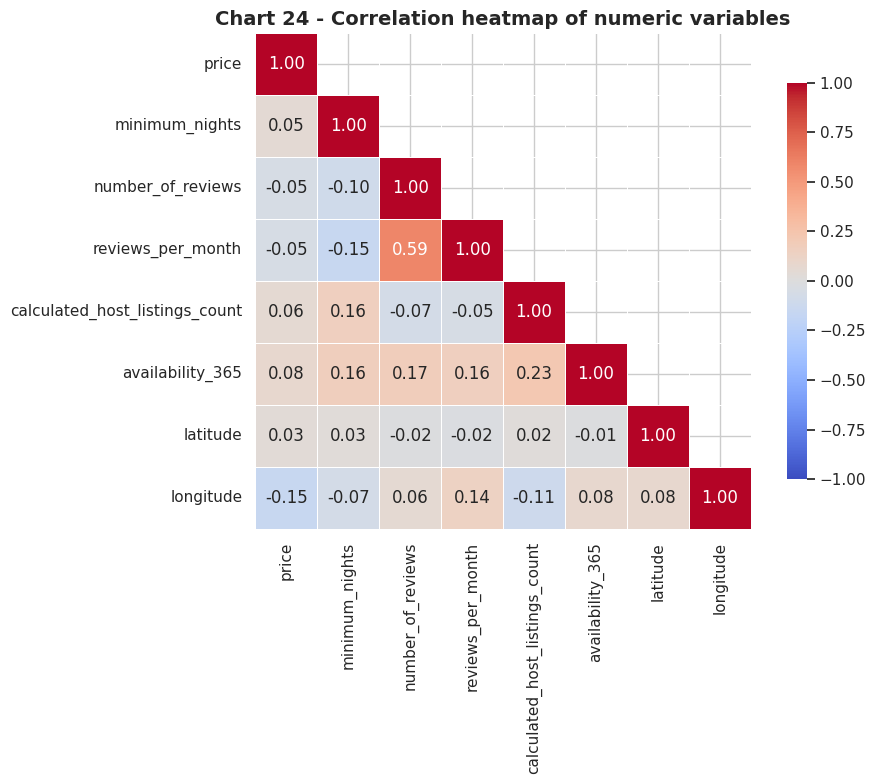

In [40]:
# Chart - 24 visualization code: correlation heatmap of the numeric variables
NUMERIC_COLS = ["price", "minimum_nights", "number_of_reviews", "reviews_per_month",
                "calculated_host_listings_count", "availability_365", "latitude", "longitude"]
corr = df[NUMERIC_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)    # hide the duplicate upper triangle

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
finish(ax, "Chart 24 - Correlation heatmap of numeric variables")

##### 1. Why did you pick this chart?
A correlation heatmap summarises every pairwise linear relationship between the numeric variables in one view. Masking the upper triangle removes the duplicates.

##### 2. What insights did you find?
Most correlations are weak (|r| ≤ 0.17). The strongest is `number_of_reviews` and `reviews_per_month` (**0.59**), as expected. Host listing count and availability (**0.23**): bigger hosts keep listings open more. **Price has no meaningful linear link to any numeric variable**; its largest is with longitude (−0.15, cheaper further east). Minimum nights is negatively related to reviews per month (−0.15).

##### 3. How will these insights impact the business (positive or negative)?
- **Positive:** Numeric variables explain little of the price, so pricing tools should be built on location and room type (Charts 10, 11 and 23).
- **Negative:** Weak linear relationships mean a simple linear model would predict price or demand poorly. A future model needs categorical location features and non-linear methods.

#### Chart - 25 - Pair plot
*Multivariate – key numeric variables by room type*

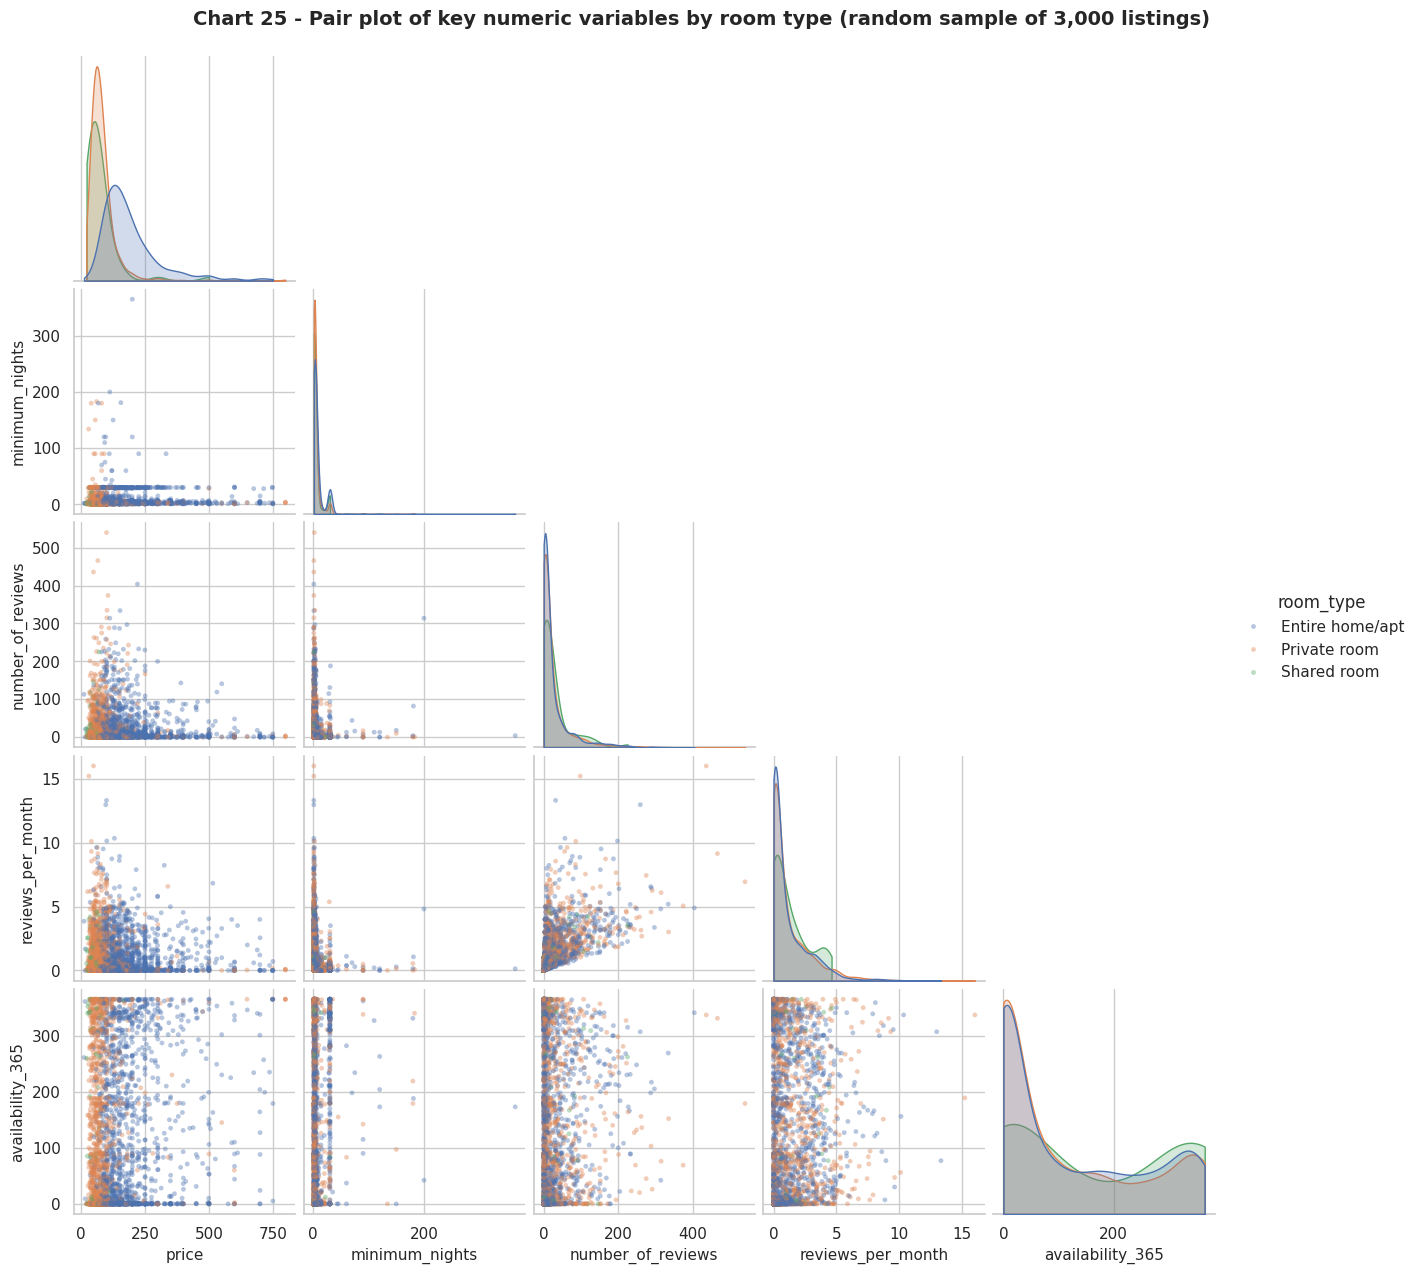

In [41]:
# Chart - 25 visualization code: pair plot of the main numeric variables (random sample for speed and readability)
PAIR_COLS = ["price", "minimum_nights", "number_of_reviews", "reviews_per_month", "availability_365"]
pair_sample = dfp.sample(n=3000, random_state=42)
grid = sns.pairplot(pair_sample, vars=PAIR_COLS, hue="room_type", hue_order=ROOM_ORDER, palette=ROOM_COLORS,
                    corner=True, plot_kws={"alpha": 0.4, "s": 12, "linewidth": 0}, diag_kws={"common_norm": False, "cut": 0})
grid.figure.suptitle("Chart 25 - Pair plot of key numeric variables by room type (random sample of 3,000 listings)",
                     y=1.02, fontsize=14, fontweight="bold")
plt.show()

##### 1. Why did you pick this chart?
A pair plot shows every pairwise scatter plus each variable's distribution, split by room type. It is a final multivariate check for patterns the earlier charts may have missed; a random sample of 3,000 listings keeps it fast and readable.

##### 2. What insights did you find?
All five variables are strongly right-skewed. Entire homes sit higher on price in every panel, while private and shared rooms dominate the low-price, high-review region. Availability is bimodal for every room type (peaks at 0 and near 365 days), with shared rooms leaning towards high availability. There is no clear linear structure between price and reviews or availability, which confirms Chart 24; `number_of_reviews` and `reviews_per_month` rise together.

##### 3. How will these insights impact the business (positive or negative)?
- **Positive:** It confirms that segmenting by room type (and location) is the right basis for pricing and marketing decisions.
- **Negative:** Heavily skewed variables and weak linear links mean any future price model needs transformations (for example, log price) and richer features, not just raw numeric inputs.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ? Explain Briefly.

1. **Grow supply where demand is strongest.** Staten Island, the Bronx and Queens have the fewest listings but the highest review rates: 1.2–1.4 reviews a month, against 0.6 in Manhattan and Brooklyn (Charts 1 and 18). Recruit hosts there, especially for affordable private rooms near the airports and subway lines, which is the formula of the busiest hosts (Chart 20).
2. **Give hosts data-driven price guidance.** Borough and room type explain price far better than any numeric variable (Charts 10, 11, 23 and 24). A suggested price based on the borough × room-type (and neighbourhood) median would replace round-number guessing (Chart 3) and flag over-priced listings: luxury listings average 11 reviews, against 25 for listings under \$200 (Chart 19).
3. **Clean up dormant inventory.** 35.9% of listings cannot be booked on any day of the next year, and 25.8% also have no review in the last 12 months (Charts 5 and 7). Prompt hosts to update their calendars, and lower the search ranking of (or archive) inactive listings so guests only see homes they can book.
4. **Help new listings win their first booking.** One in five listings has never been reviewed (Chart 6). First-booking discounts and a "new listing" badge would help, and so would shorter minimum stays where allowed: reviews per month drop from 1.6 for a 1-night minimum to 0.3 for a 30-night minimum (Chart 13).
5. **Manage commercial hosting and regulatory risk.** 0.3% of hosts control 6.1% of listings, and large operators run year-round entire apartments, mostly with 30-night minimums (Charts 9, 15 and 20). Monitor high-volume hosts for compliance with New York's rule against renting an entire home for under 30 days, and offer monthly stays as a separate product so they don't crowd tourist search.
6. **Market each segment differently.** Promote Manhattan entire homes to families and business travellers; Williamsburg, Bedford-Stuyvesant and Bushwick as "value next to Manhattan" (Charts 8 and 22); and outer-borough private rooms to budget and airport-stopover travellers (Chart 14).

**Expected result:** more bookings per listing, higher host earnings, better guest trust (accurate availability, fair prices) and lower regulatory risk.

# **Conclusion**

This EDA of 48,870 cleaned Airbnb NYC 2019 listings answers the project's key questions:

- **Where is the supply?** It is concentrated. Manhattan and Brooklyn hold 85% of listings and ten neighbourhoods hold 48%. Entire homes (52%) and private rooms (46%) make up almost everything.
- **What drives price?** Location and room type. The median price ranges from \$65 (Bronx) to \$150 (Manhattan), an entire home costs over twice a private room, and the ten most expensive neighbourhoods are all in Manhattan. Numeric variables barely correlate with price.
- **What drives demand (reviews)?** Value and flexibility. Listings under \$200 with 1–3-night minimums collect the most reviews; luxury listings and 30-night minimums collect the fewest. Price and review counts are almost unrelated (r = −0.05).
- **Which hosts are the busiest, and why?** Small hosts with cheap private rooms, 1-night minimums and good transport links: Maya, Danielle and Angela next to LaGuardia Airport, Len in Prospect Heights and Jj in Harlem. The biggest hosts by listings (Sonder and Blueground) are companies renting Manhattan apartments that are open most of the year, and they generate relatively few reviews.
- **Is there a difference in traffic between areas?** Yes. Outer-borough listings are reviewed about twice as often as those in Manhattan and Brooklyn. Lower prices, more private rooms, airport proximity and less competition per listing are the likely reasons.
- **What are the risks?** About a quarter of listings look dormant, one in five has never been reviewed, and commercial-scale hosting of entire apartments carries regulatory risk in New York.

**Limitations:** reviews are only a proxy for bookings; `availability_365 = 0` can mean fully booked or blocked by the host; and this is a single 2019 snapshot of listed (not paid) prices. A natural next step is a price-recommendation model built on location, room type and host features, together with booking data over time.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***